In [39]:
import sys
import os

# Проверяем, запущен ли ноутбук в среде Google Colab
if "google.colab" in sys.modules:
    !pip install uv -q
    !wget https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_1/pyproject.toml -q
    !uv pip install -r pyproject.toml --system -q
    os.kill(os.getpid(), 9)  # force runtime restart

# Курс по прогнозированию временных рядов

# Неделя 3.

# Преобразование Фурье, спектр временного ряда

https://habr.com/ru/articles/892564/

PDF про преобразование Фурье

In [40]:
import numpy as np
from matplotlib import pyplot
from pandas import DataFrame, Series, read_parquet
from scipy.fft import fft, fftfreq, ifft
from scipy.signal import periodogram
from statsmodels.nonparametric.smoothers_lowess import lowess

In [41]:
pyplot.rcParams["figure.autolayout"] = True
pyplot.rcParams["figure.figsize"] = (14, 7)

Основными компонентами, на которые может быть разложен сигнал, являются: амплитуда, частота и фаза.

**Амплитуда** - это максимальное значение смещения или изменения переменной величины от среднего значения сигнала при его колебательном или волновом движении. Как правило безразмерная величина, которая показывает, насколько сильно проявляется сигнал.

**Частота** - это количество повторяющихся колебаний или циклов сигнала, совершаемых за единицу времени. Измеряется в герцах.

**Фаза** - это сдвиг сигнала относительно начала отсчёта времени или другого сигнала, указывающий в какой момент времени начинается одно полное колебание или цикл. Измеряется в градусах или радианах.

Более подробно - Peter Bloomfield. Fourier analysis of time series: an introduction Second Editionce, Wiley Series in Probability and Statistics, 2, 2013

Примером периодического сигнала является синусоидальный сигнал. 

Сначала с помощью параметра n задаётся общее количество точек сигнала (=длина сигнала), а затем с помощью функции np.arange(0, 1, 1/n) создаётся массив моментов времени time_vec с равномерно распределёнными между 0 и 1 секундой шагами 1/n. В первом рассматриваемом примере сигнала массив time_vec содержит моменты времени, равномерно распределённые между 0 и 1 секундой с шагом 0.001. Все рассматриваемые далее сигналы будут находиться в интервале от 0 до 1 секунды (их длительность будет считаться равной одной секунде).

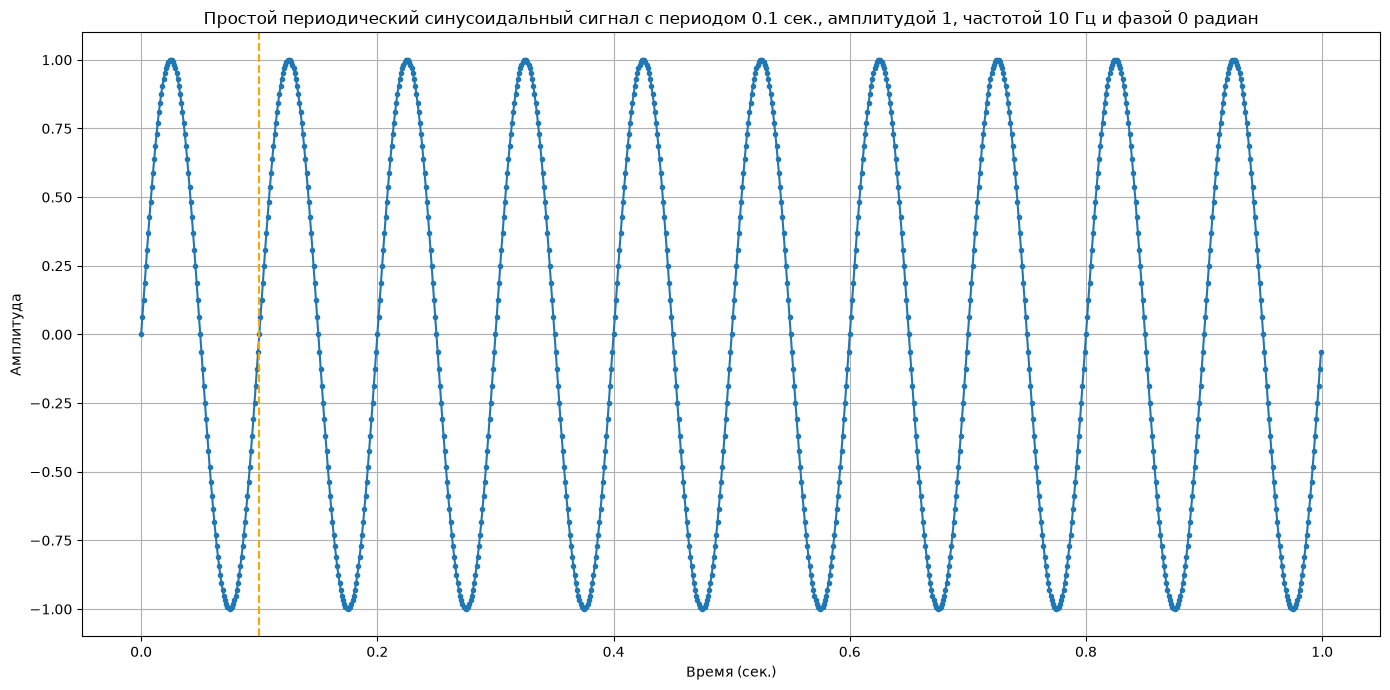

In [42]:
n = 1000
time_vec = np.arange(0, 1, 1 / n)
A = 1
f = 10
phi = 0

xt = A * np.sin(2 * np.pi * f * time_vec + phi)

pyplot.figure()
pyplot.plot(time_vec, xt, marker=".")
pyplot.axvline(x=time_vec[100], color="orange", linestyle="dashed")
pyplot.xlabel("Время (сек.)")
pyplot.ylabel("Амплитуда")
text_1 = "Простой периодический синусоидальный сигнал с периодом 0.1 сек., "
text_2 = "амплитудой 1, частотой 10 Гц и фазой 0 радиан"
pyplot.title(text_1 + text_2)
pyplot.grid(True)
pyplot.show()

Видно, что это периодический сигнал: имеется 10 полных повтора (или цикла); длительность каждого цикла, называемая периодом, составляет 0.1 секунду. Частота 10 Гц означает, что в одну секунду в сигнале имеется 10 таких периодов. Амплитуда сигнала равна 1. А его фаза равна 0, что означает что сигнал начинается точно в начале координат.

Совокупность амплитуд и частот гармоник в разложении Фурье называют спектром сигнала.

Рассмотрим разложение периодических функций (сигналов) в ряд Фурье с помощью дискретного преобразования Фурье (далее - ДПФ). ДПФ - это математический метод, который используется для анализа частотного состава сигналов. Он преобразует сигнал из временной области в частотную, представляя его набором комплексных чисел. Каждое комплексное число соответствует одной частоте и содержит информацию о её амплитуде и фазе. Обычно количество комплексных чисел равно количеству точек сигнала, что указывает на совпадение числа частот с числом точек сигнала. Исследователи часто фокусируются на частотах, которые связаны с синусоидальными компонентами исходного сигнала.

При обработке временных рядов ДПФ полезен тем, что позволяет выявлять периодические компоненты и шумы, которые затем можно отфильтровать. Вычисления ДПФ основаны на алгоритме под названием «быстрое преобразование Фурье» (БПФ).

Python-библиотека SciPy предоставляет ряд функций для работы с сигналами, включая функции для выполнения ДПФ (scipy.fft). В данном исследовании будут рассмотрены три из них — `fft()`, `fftfreq()` и `ifft()`. Рассмотрим каждую из них по отдельности.

Функция `scipy.fft.fft()` применяется для вычисления ДПФ сигнала, используя алгоритм БПФ (в англоязычной терминологии - Fast Fourier Transform, FFT).

Основными аргументами функции, на которые хотелось обратить внимание, являются:
- x: входной массив данных, который требуется преобразовать.
- n: количество точек в выходном преобразовании.
- norm: параметр, определяющий нормализацию результата. По умолчанию None (без нормализации).

Функция `scipy.fft.fftfreq()` используется для вычисления частот, соответствующих результатам ДПФ.

Одними из основных аргументов, которые принимает данная функция, являются:
- n: количество точек в преобразовании Фурье (или размер окна, как в описании по документации).
- d: временной шаг. Или расстояние между образцами (обратное частоте дискретизации), как в описании по документации. По умолчанию d считается равным 1.

Функция `scipy.fft.ifft()` используется для вычисления обратного ДПФ (в англоязычной терминологии - Inverse Fast Fourier Transform, IFFT). Эта функция позволяет преобразовывать данные из частотной области обратно во временную область.

Обязательным аргументом функции является:
- x: массив комплексных чисел, представляющих частотные компоненты, которые необходимо преобразовать обратно во временную область. Это может быть массив любого размерности. О комплексных числах будет рассказано далее.
Необязательный аргумент:
- n: количество точек для обратного преобразования.

Функция `scipy.fft.fft()` вычисляет ДПФ, но сама по себе не учитывает частоту выборки данных. Поэтому для интерпретации результатов ДПФ необходимо использовать функцию `scipy.fft.fftfreq()`, чтобы получить соответствующие частоты для каждого элемента выходного спектра.

В python комплексное число имеет тип complex и состоит из двух чисел с плавающей точкой, представляющих его действительную и мнимую части. Для представления мнимой части используется j (число, оканчивающееся на j, считается мнимым). При этом у комплексных чисел есть атрибуты real и imag для получения действительной или мнимой части соответственно. Действительная и мнимая части комплексного числа в результате ДПФ не являются амплитудой и фазой напрямую, но они могут быть использованы для расчёта этих величин: для отдельного получения модуля (амплитуды) используется функция np.abs(), для отдельного получения угла - np.angle(). 

In [43]:
# (1+2j)
x = complex(1, 2)
print(x)

# (3+4j)
y = complex(3, 4)
print(y)

# (4+6j)
z = x + y
print(z)

print(z.real)

print(z.imag)

print(np.abs(z))

print(np.angle(z))

(1+2j)
(3+4j)
(4+6j)
4.0
6.0
7.211102550927979
0.982793723247329


Применим к сигналу функции `fft()` и `fftfreq()` - и вычислим ДПФ и соответствующие её результатам частоты. Тем самым мы получим спектр рассматриваемого сигнала. Затем построим график, на котором выведем как исходный сигнал, так и полученный спектр.

`freg_fft = fftfreq(n=n)`

Сперва создаётся копия оригинального массива, чтобы избежать его изменений. Затем выбирается только первая половина значений частот, поскольку после выполнения ДПФ спектр имеет симметричную структуру, и положительные частоты содержат всю необходимую информацию о частотном содержании сигнала, в то время как отрицательные частоты являются их зеркальным отражением. Далее выполняется деление на «/(1/n)», чтобы частоты соответствовали диапазону фактического сигнала.

`y_fft = fft(x=xt)`

Сначала создаётся копия оригинального массива и берётся только первая половина значений комплексных чисел, полученных из ДПФ (из-за симметрии спектра); далее из этой половины значений извлекается модуль (=получаем амплитуды). Умножение на «*(2/n)» выполняется для масштабирования амплитуд к фактическим значениям сигнала. Это умножение на 2 учитывает вклад как положительных, так и отрицательных частот, поскольку амплитуды для действительных сигналов симметричны.

В конце применяется срез [:50] как к частотам, так и к амплитудам, чтобы отобразить только первые 50 значений для удобного восприятия информации.

Результаты ДПФ удобно представить с помощью диаграммы stem plot.

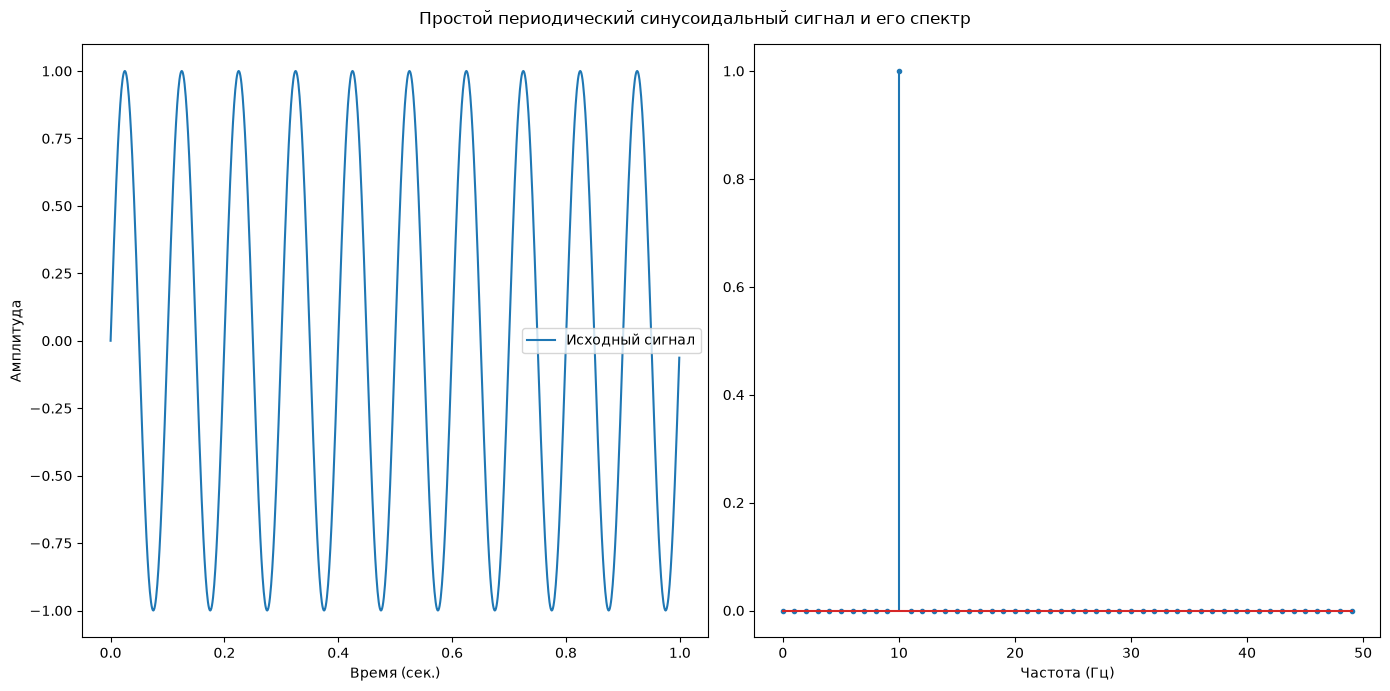

In [44]:
freg_fft = fftfreq(n=n)
y_fft = fft(x=xt)

fig, axs = pyplot.subplots(1, 2)
axs[0].plot(time_vec, xt, label="Исходный сигнал")
axs[0].set_xlabel("Время (сек.)")
axs[0].set_ylabel("Амплитуда")
axs[0].legend(loc="best")
axs[1].stem(
    (freg_fft.copy()[: n // 2] / (1 / n))[:50],
    (np.abs(y_fft.copy()[: n // 2]) * (2 / n))[:50],
    markerfmt=".",
)
axs[1].set_xlabel("Частота (Гц)")
pyplot.suptitle("Простой периодический синусоидальный сигнал и его спектр")
pyplot.show()

In [52]:
freg_fft[:20] * n # Частоты

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19.])

In [58]:
np.round(2 * np.abs(y_fft[:20]) / n, 3) # Амплитуды частот

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.])

В итоге мы легко можем оценить, какие частоты присутствуют в сигнале и с какой амплитудой: в данном сигнале имеется одна-единственная частота 10 Гц с амплитудой, равной 1. Зная это, мы легко может воспроизвести (=восстановить) исходный сигнал с помощью разных методов, которые будут рассмотрены далее. В этом примере давайте восстановим сигнал «вручную»:

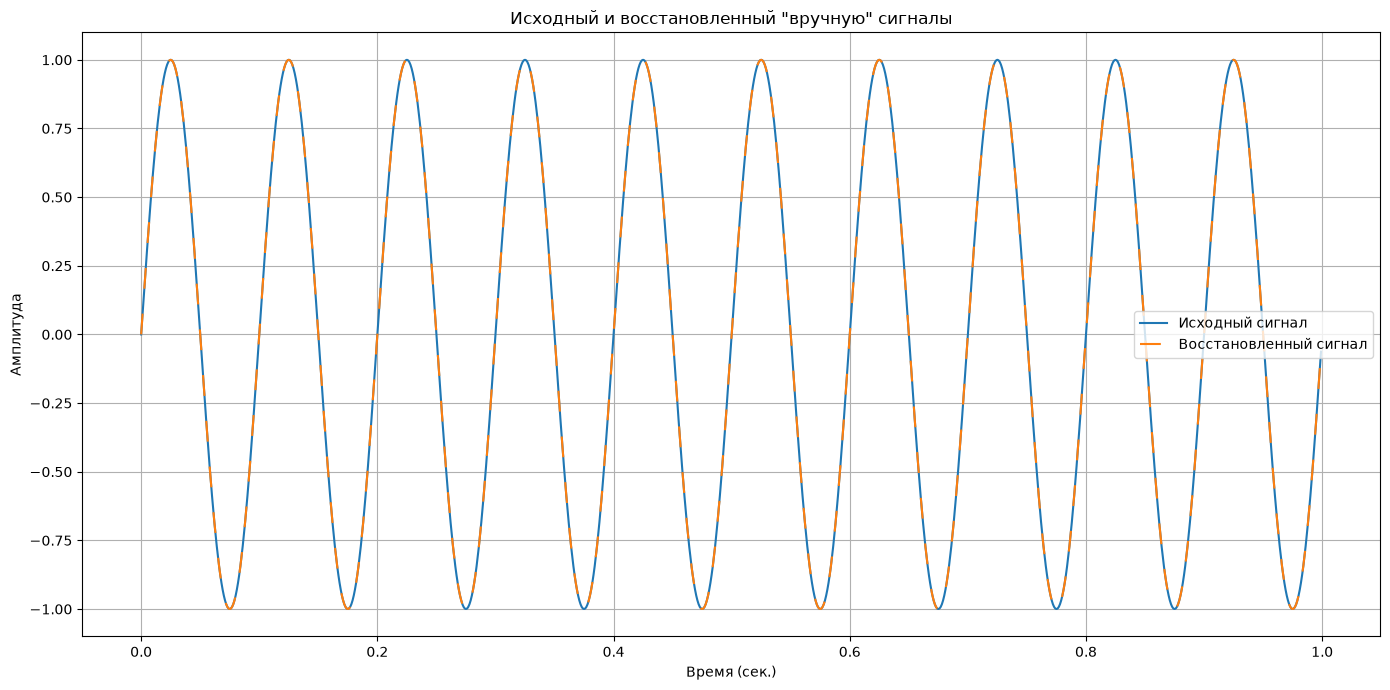

In [59]:
A_inv, f_inv, phi = 1, 10, 0
x_inv = A_inv * np.sin(2 * np.pi * f_inv * time_vec + phi)

pyplot.figure()
pyplot.plot(time_vec, xt, label="Исходный сигнал")
pyplot.plot(time_vec, x_inv, dashes=[10, 12], label="Восстановленный сигнал")
pyplot.xlabel("Время (сек.)")
pyplot.ylabel("Амплитуда")
pyplot.legend(loc="best")
pyplot.title('Исходный и восстановленный "вручную" сигналы')
pyplot.grid(True)
pyplot.show()

Создадим сигнал посложнее:

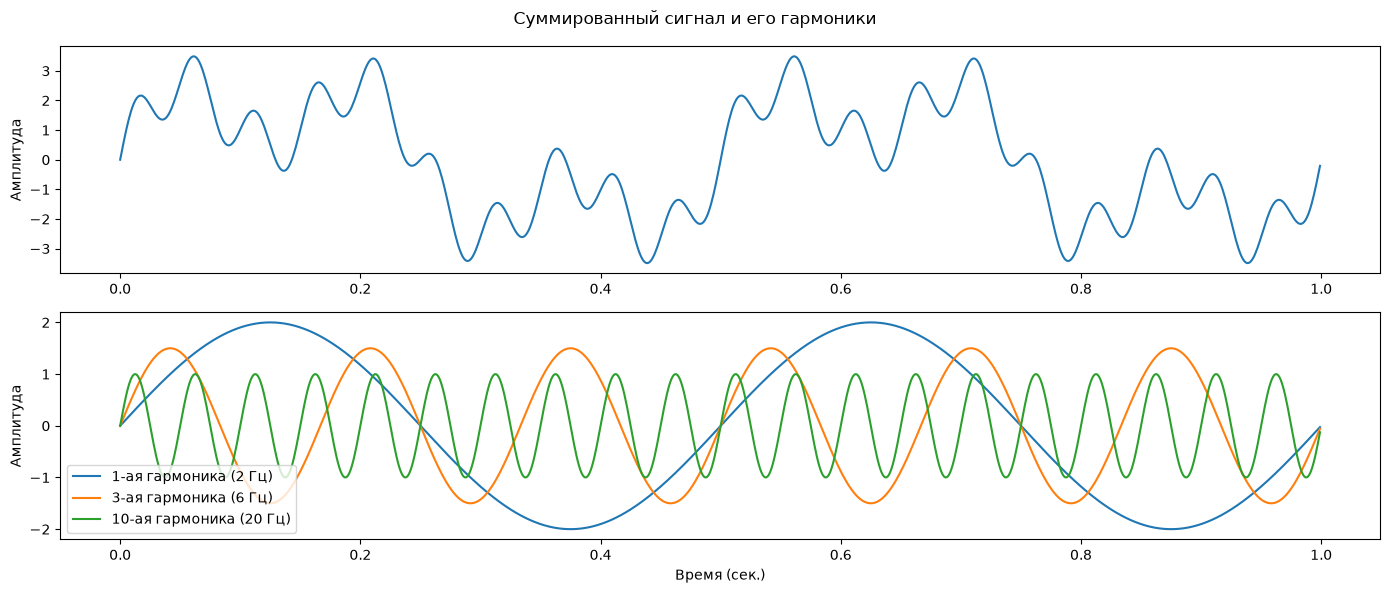

In [60]:
n = 1000
time_vec = np.arange(0, 1, 1 / n)

A1, f1 = 2, 2
xt1 = A1 * np.sin(2 * np.pi * f1 * time_vec)
A2, f2 = 1.5, 6
xt2 = A2 * np.sin(2 * np.pi * f2 * time_vec)
A3, f3 = 1, 20
xt3 = A3 * np.sin(2 * np.pi * f3 * time_vec)

sum_signal = xt1 + xt2 + xt3

fig, axs = pyplot.subplots(2, 1, figsize=(14, 6))
axs[0].plot(time_vec, sum_signal)
axs[0].set_ylabel("Амплитуда")
axs[1].plot(time_vec, xt1, label="1-ая гармоника (2 Гц)")
axs[1].plot(time_vec, xt2, label="3-ая гармоника (6 Гц)")
axs[1].plot(time_vec, xt3, label="10-ая гармоника (20 Гц)")
axs[1].set_xlabel("Время (сек.)")
axs[1].set_ylabel("Амплитуда")
axs[1].legend(loc="best")
pyplot.suptitle("Суммированный сигнал и его гармоники")
pyplot.show()

Рассчитаем его спектр и выведем результат на графике:

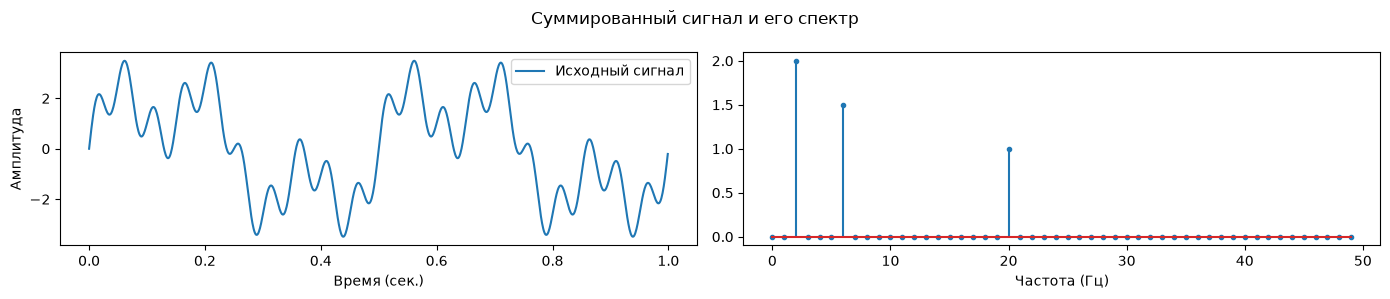

In [61]:
y_fft = fft(x=sum_signal)
freg_fft = fftfreq(n=n)

fig, axs = pyplot.subplots(1, 2, figsize=(14, 3))
axs[0].plot(time_vec, sum_signal, label="Исходный сигнал")
axs[0].set_xlabel("Время (сек.)")
axs[0].set_ylabel("Амплитуда")
axs[0].legend(loc="best")
axs[1].stem(
    (freg_fft.copy()[: n // 2] / (1 / n))[:50],
    (np.abs(y_fft.copy()[: n // 2]) * (2 / n))[:50],
    markerfmt=".",
)
axs[1].set_xlabel("Частота (Гц)")
pyplot.suptitle("Суммированный сигнал и его спектр")
pyplot.show()

С помощью функции `ifft()` восстановим сигнал по массиву комплексных чисел, полученных в результате выполнения ДПФ:

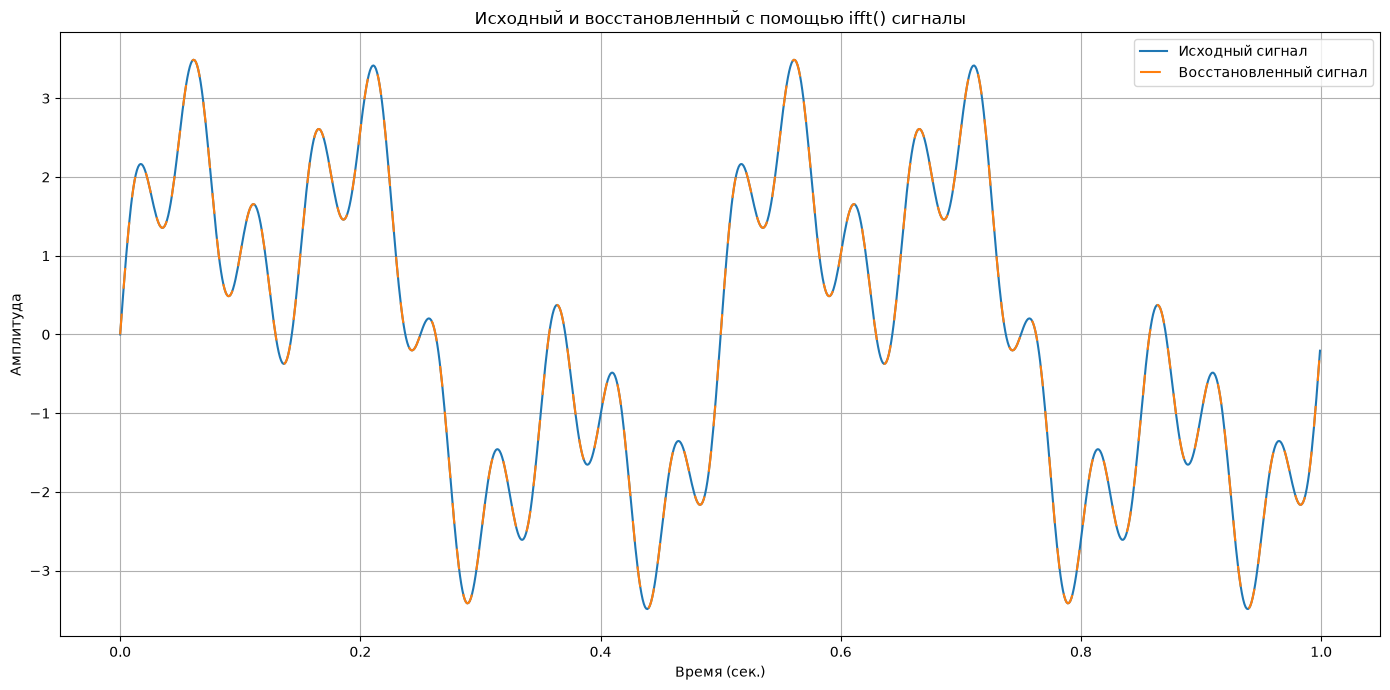

In [62]:
x_inv = ifft(y_fft)

pyplot.figure()
pyplot.plot(time_vec, sum_signal, label="Исходный сигнал")
pyplot.plot(time_vec, x_inv.real, dashes=[10, 12], label="Восстановленный сигнал")
pyplot.xlabel("Время (сек.)")
pyplot.ylabel("Амплитуда")
pyplot.legend(loc="best")
pyplot.title("Исходный и восстановленный с помощью ifft() сигналы")
pyplot.grid(True)
pyplot.show()

Выполним фильтрацию сигнала и избавимся от самой высокой частоты, приняв её за шум.

Рассмотрим два способа эмпирическрй фильтрации.

Первый способ представляет собой фильтрацию по заданным частотам. Сперва определяется список `fregs_for_stay` с частотами, которые требуется оставить (в данном примере это 2 и 6 Гц и, соответственно, их зеркальные отражения). Далее создаётся маска, проверяющая вхождение полученных частот в фактическом масштабе в указанный список. Если маска истина, значение из `y_fft` сохраняется, в противном случае оно заменяется на 0.

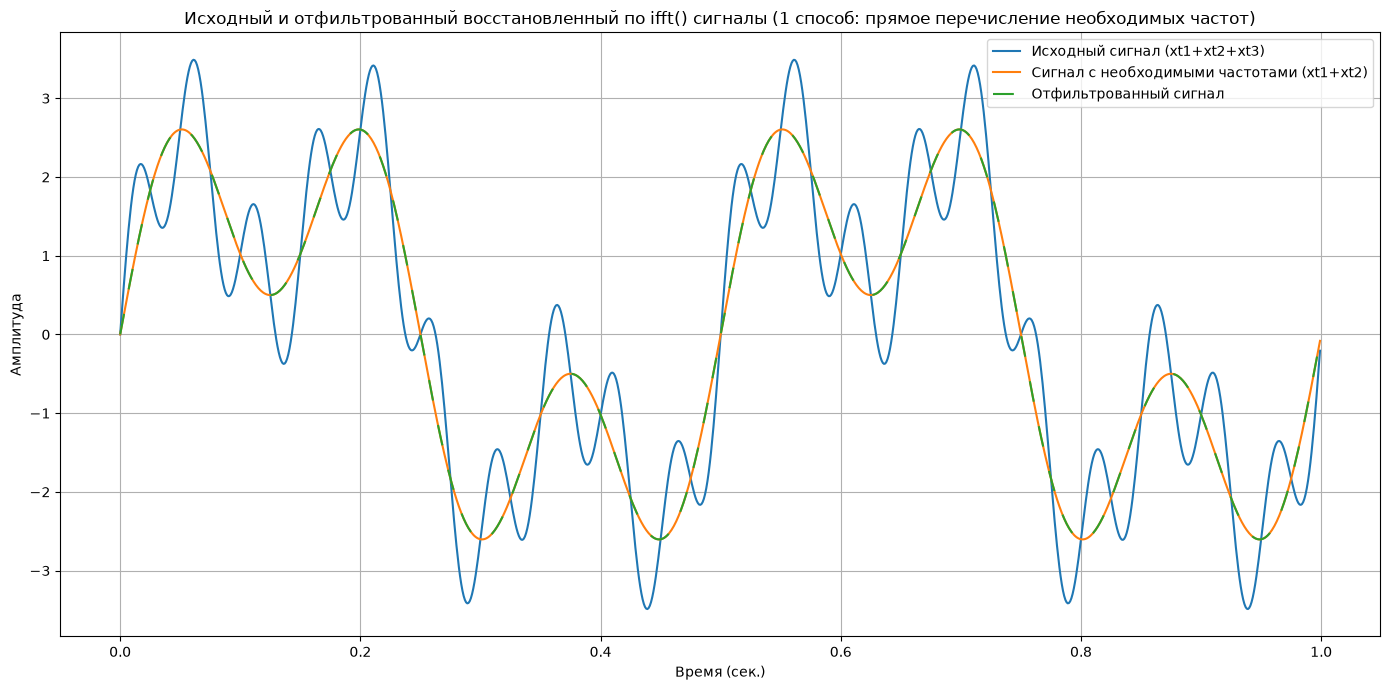

In [63]:
fregs_for_stay = [2, 6]
mask = np.isin(np.abs(freg_fft) / (1 / n), fregs_for_stay)
filtered_fft = np.where(mask, y_fft, 0) # Занулили все что в остальных частотах

x_inv = ifft(filtered_fft)

pyplot.figure()
pyplot.plot(time_vec, sum_signal, label="Исходный сигнал (xt1+xt2+xt3)")
pyplot.plot(time_vec, xt1 + xt2, label="Сигнал с необходимыми частотами (xt1+xt2)")
pyplot.plot(time_vec, x_inv.real, dashes=[10, 12], label="Отфильтрованный сигнал")
pyplot.xlabel("Время (сек.)")
pyplot.ylabel("Амплитуда")
pyplot.legend(loc="best")
text_1 = "Исходный и отфильтрованный восстановленный по ifft() "
text_2 = "сигналы (1 способ: прямое перечисление необходимых частот)"
pyplot.title(text_1 + text_2)
pyplot.grid(True)
pyplot.show()

Второй способ — частотная фильтрация сигнала по пороговым значениям. Сперва устанавливаются нижний `cutoff_low` и верхний `cutoff_high` пороги для фильтрации преобразованных частот. Затем создаётся маска, которая проверяет, находятся ли частоты в пределах заданных порогов. Значения из `y_fft` сохраняются, если маска истинна; в противном случае они заменяются на 0.

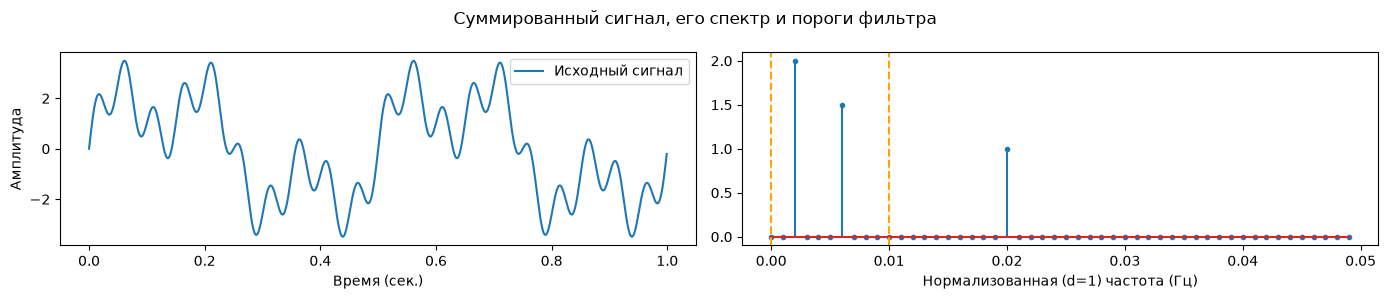

In [65]:
fig, axs = pyplot.subplots(1, 2, figsize=(14, 3))
axs[0].plot(time_vec, sum_signal, label="Исходный сигнал")
axs[0].set_xlabel("Время (сек.)")
axs[0].set_ylabel("Амплитуда")
axs[0].legend(loc="best")
axs[1].stem(freg_fft.copy()[:50], np.abs(y_fft.copy()[:50]) * (2 / n), markerfmt=".")
axs[1].axvline(x=freg_fft[0], color="orange", linestyle="dashed")
axs[1].axvline(x=freg_fft[10], color="orange", linestyle="dashed")
axs[1].set_xlabel("Нормализованная (d=1) частота (Гц)")
pyplot.suptitle("Суммированный сигнал, его спектр и пороги фильтра")
pyplot.show()

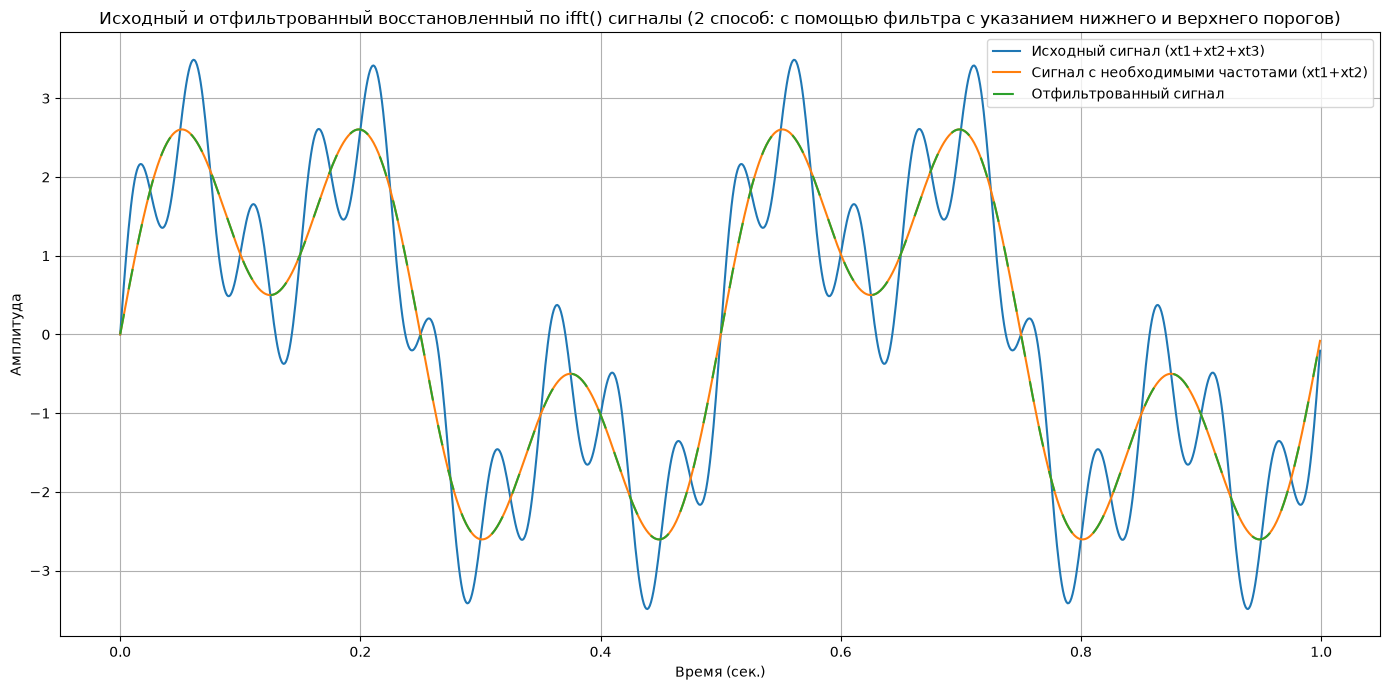

In [66]:
cutoff_low = 0.0
cutoff_high = 0.01
mask = (np.abs(freg_fft) >= cutoff_low) & (np.abs(freg_fft) <= cutoff_high)
filtered_fft = np.where(mask, y_fft, 0)

x_inv = ifft(filtered_fft)

pyplot.figure()
pyplot.plot(time_vec, sum_signal, label="Исходный сигнал (xt1+xt2+xt3)")
pyplot.plot(time_vec, xt1 + xt2, label="Сигнал с необходимыми частотами (xt1+xt2)")
pyplot.plot(time_vec, x_inv.real, dashes=[10, 12], label="Отфильтрованный сигнал")
pyplot.xlabel("Время (сек.)")
pyplot.ylabel("Амплитуда")
pyplot.legend(loc="best")
text_1 = "Исходный и отфильтрованный восстановленный по ifft() "
text_2 = "сигналы (2 способ: с помощью фильтра с указанием нижнего и верхнего порогов)"
pyplot.title(text_1 + text_2)
pyplot.grid(True)
pyplot.show()

Следующий сигнал создадим с помощью функции `np.cos()`, и добавим равномерный шум. Для генерации равномерного шума применим функцию `np.random.uniform()`, которая создаст случайные числа, равномерно распределённые между двумя заданными границами: для примера возьмём -1.5 и 1.5.

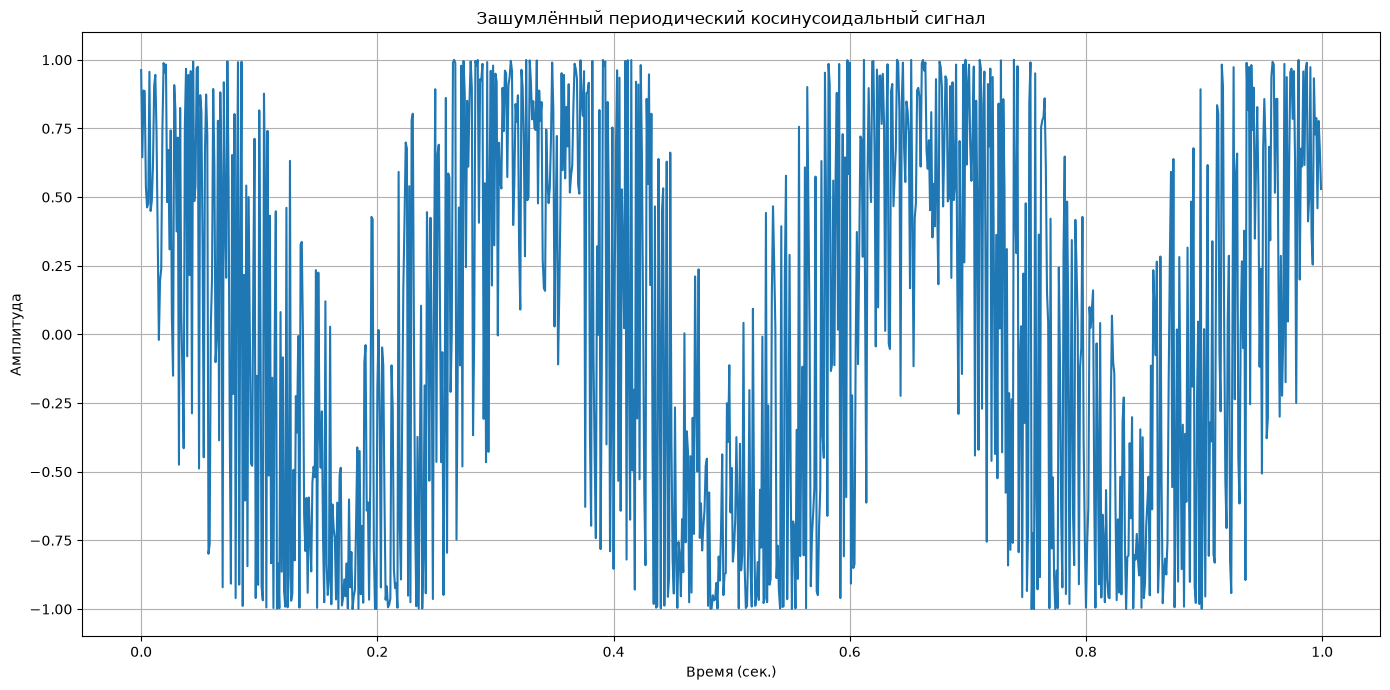

In [67]:
n = 1000
time_vec = np.arange(0, 1, 1 / n)
A, f = 1, 3
uniform_noise = np.random.uniform(-1.5, 1.5, size=time_vec.size)

xt = A * np.cos(2 * np.pi * f * time_vec + uniform_noise)

pyplot.figure()
pyplot.plot(time_vec, xt)
pyplot.xlabel("Время (сек.)")
pyplot.ylabel("Амплитуда")
pyplot.title("Зашумлённый периодический косинусоидальный сигнал")
pyplot.grid(True)
pyplot.show()

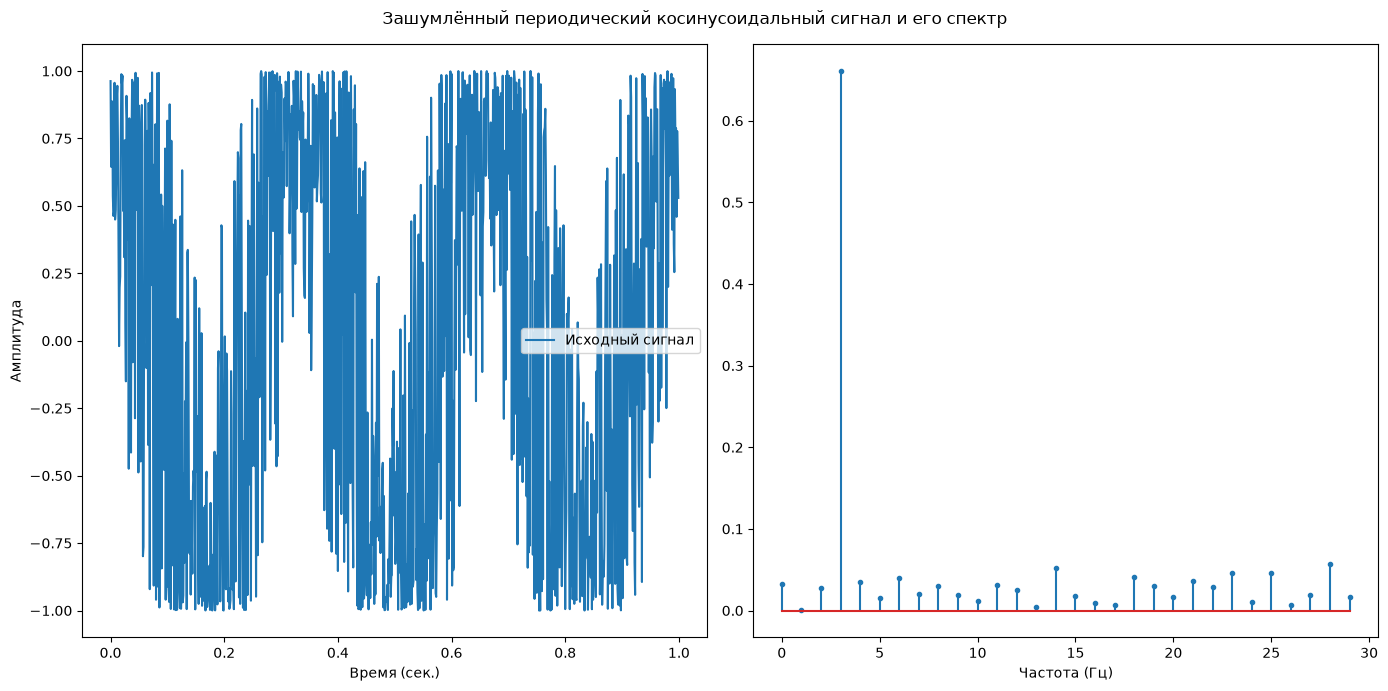

In [68]:
y_fft = fft(x=xt)
freg_fft = fftfreq(n=n)

fig, axs = pyplot.subplots(1, 2)
axs[0].plot(time_vec, xt, label="Исходный сигнал")
axs[0].set_xlabel("Время (сек.)")
axs[0].set_ylabel("Амплитуда")
axs[0].legend(loc="center right")
axs[1].stem(freg_fft.copy()[:30] / (1 / n), np.abs(y_fft.copy()[:30]) * (2 / n), markerfmt=".")
axs[1].set_xlabel("Частота (Гц)")
pyplot.suptitle("Зашумлённый периодический косинусоидальный сигнал и его спектр")
pyplot.show()

Обратите внимание, согласно спектру амплитуда сигнала на третьей частоте равна приблизительно 0.65, а не 1, как было указано при создании сигнала. Это произошло из-за добавления случайного шума к каждой точке сигнала, включая точку на третьей частоте, который может варьироваться от -1.5 до 1.5.

Создадим маску и отфильтруем сигнал, оставив только частоту 3 (и, следовательно, её зеркальное отражение n-3). Напоминаю, что частоты спектра распределены симметрично относительно его середины. У них одинаковая действительная часть, но мнимая часть имеет противоположные знаки. Это делает их комплексно-сопряжёнными числами, особенность которых заключается в том, что они позволяют упростить вычисления и представить сигналы в более компактной и удобной форме. В связи с этим важно отметить, что для получения исходного сигнала необходимо учитывать ещё и зеркальные частоты (с противоположной фазой). Без них восстановление сигнала может привести к искажению или неправильной интерпретации.

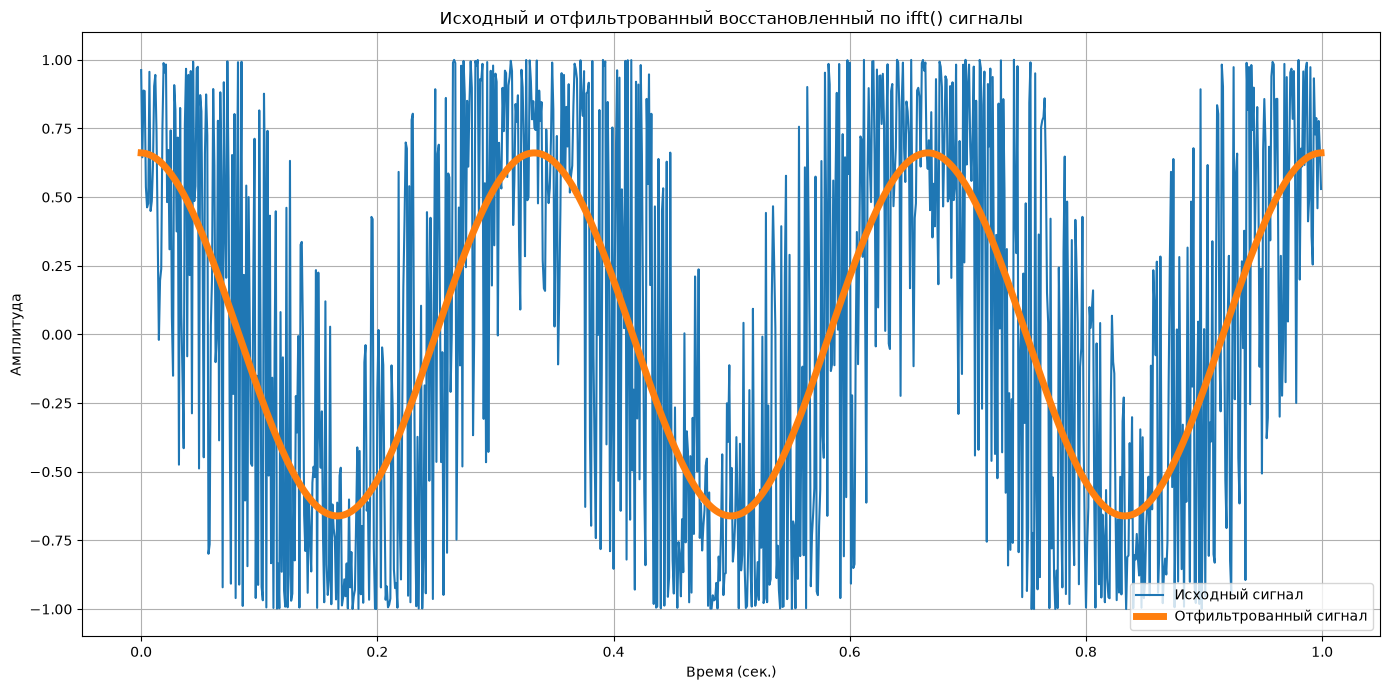

In [69]:
mask = np.abs(freg_fft) / (1 / n) == 3
filtered_fft = np.where(mask, y_fft, 0)

x_inv = ifft(filtered_fft)

pyplot.figure()
pyplot.plot(time_vec, xt, label="Исходный сигнал")
pyplot.plot(time_vec, x_inv.real, linewidth=5, label="Отфильтрованный сигнал")
pyplot.xlabel("Время (сек.)")
pyplot.ylabel("Амплитуда")
pyplot.legend(loc="best")
pyplot.title("Исходный и отфильтрованный восстановленный по ifft() сигналы")
pyplot.grid(True)
pyplot.show()

Перейдём к последнему и наиболее близкому к нашему случаю примеру сигнала. Сперва создадим для него несколько сезонных компонент — годовую, недельную и дневную, а также добавим гауссовский шум, который хорошо подходит для создания случайной изменчивости (помех в сигнале). Для генерации гауссовского (или нормального) шума применим функцию `np.random.randn()` с коэффициентов 2.5, которая создаст случайные числа, распределённые по нормальному закону со средним значением 0 и стандартным отклонением 2.5.

Для их выявления будем использовать как спектрограмму, так и периодограмму из библиотеки scipy. С аргументом `scaling='density'` (по умолчанию) периодограмма представляет собой оценку спектральной плотности мощности сигнала. В отличие от спектрограммы, она менее чувствительна к шуму, что позволяет более наглядно выделить частоты, характеризующиеся значительными сезонными колебаниями (сезонные компоненты). В то же время высокочастотные гармоники становятся менее заметными, поэтому вместе с периодограммой будем рассматривать также и спектрограмму сигнала.

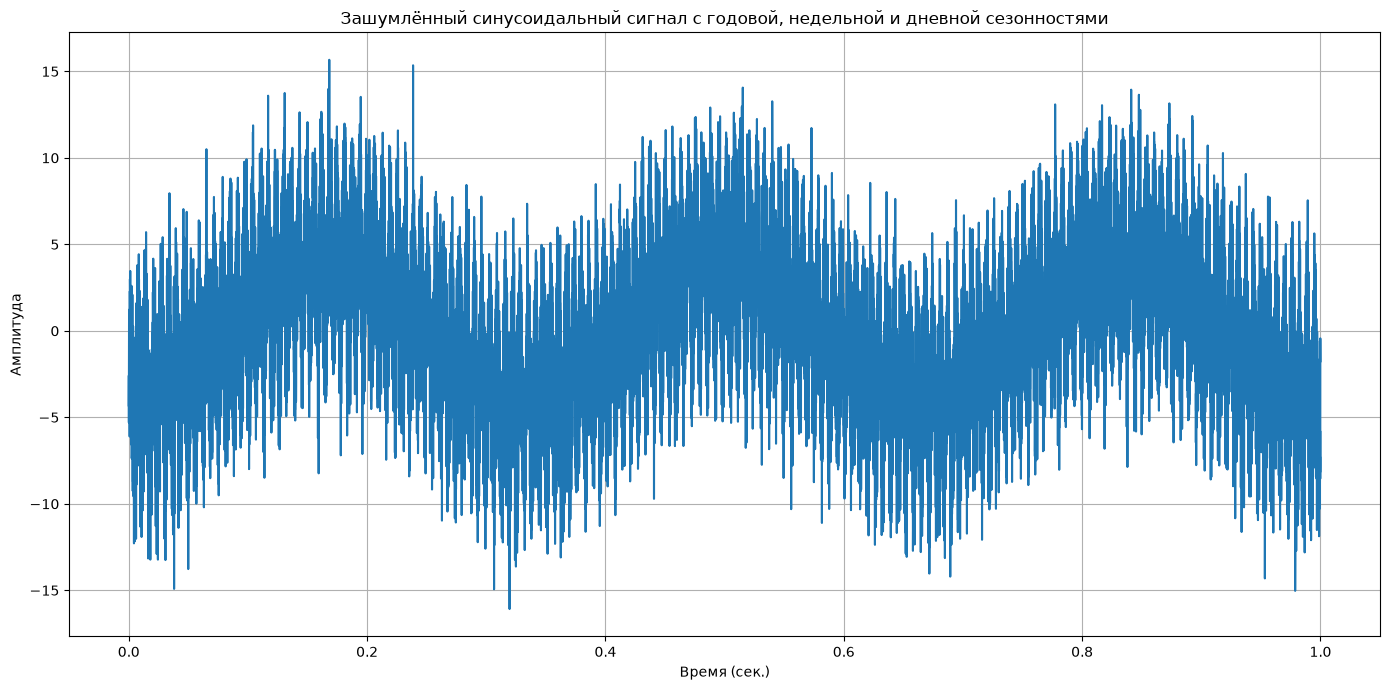

In [71]:
n = 26280
time_vec = np.arange(0, 1, 1 / n)

A_year, A_week, A_day = 4, 3, 1.5
phi = -np.pi / 2

xt_year = A_year * np.sin(2 * np.pi * 3 * time_vec + phi)
xt_week = A_week * np.sin(2 * np.pi * (3 * 52) * time_vec)
xt_day = A_day * np.sin(2 * np.pi * (3 * 365) * time_vec)

norm_noise = 2.5 * np.random.randn(time_vec.size)

signal = xt_year + xt_week + xt_day + norm_noise

pyplot.figure()
pyplot.plot(time_vec, signal)
pyplot.xlabel("Время (сек.)")
pyplot.ylabel("Амплитуда")
text_1 = "Зашумлённый синусоидальный сигнал с годовой, "
text_2 = "недельной и дневной сезонностями"
pyplot.title(text_1 + text_2)
pyplot.grid()
pyplot.show()

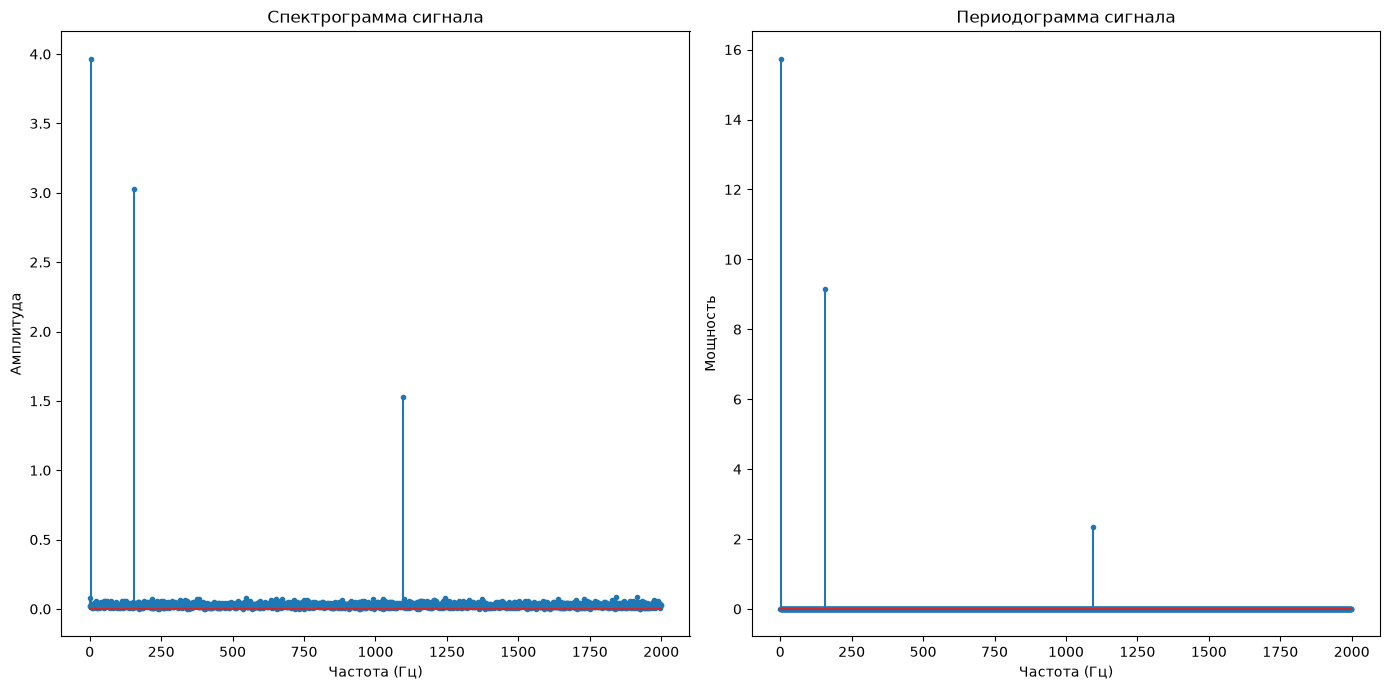

In [72]:
y_fft = fft(x=signal)
freg_fft = fftfreq(n=n)

periodogramma = periodogram(x=signal)

fig, axs = pyplot.subplots(1, 2)
axs[0].stem(freg_fft.copy()[:2000] / (1 / n), np.abs(y_fft.copy()[:2000]) * (2 / n), markerfmt=".")
axs[0].set_xlabel("Частота (Гц)")
axs[0].set_ylabel("Амплитуда")
axs[0].set_title("Спектрограмма сигнала")
axs[1].stem((periodogramma[0][:2000] / (1 / n)), (periodogramma[1][:2000] * (2 / n)), markerfmt=".")
axs[1].set_xlabel("Частота (Гц)")
axs[1].set_ylabel("Мощность")
axs[1].set_title("Периодограмма сигнала")
pyplot.show()

По графикам видно, что в сигнале имеется три сезонные компоненты - годовая на частоте 3 Гц (3x1), недельная на частоте 156 Гц (3x52) и дневная на частоте 1095 Гц (3x365). Поскольку мы передали аргументу функции `fftfreq()` общее количество точек сигнала n, то показаны совокупные результаты для всех 3-х периодов, отсюда и деление/умножение на 3 при их интерпретации.

Компоненту с самой низкой частотой называют основной. В нашем случае у основной частоты (годовая) самая большая амплитуда, поэтому это ещё и доминирующая частота. Периодограмма более сфокусировано выделила сезонные компоненты путём возведения в квадрат амплитуд ДПФ, в то время как шум стал менее заметным.

Для более удобной интерпретации полученных результатов применим такое понятие, как частота дискретизации (ЧД). В контексте анализа временных рядов, ЧД определяет количество наблюдений (или выборок) за единицу времени. В этой связи важно точно определить, какой промежуток времени считать единицей измерения. В данном примере сигнал имеет 3 годовых периода, каждый из которых, напоминаю, насчитывает 8760 часовых наблюдений в год (3х24х365). В этой связи частота дискретизации 8760 точек в год (годовая единица времени) позволит корректно сопоставить результаты анализа с реальными данными.

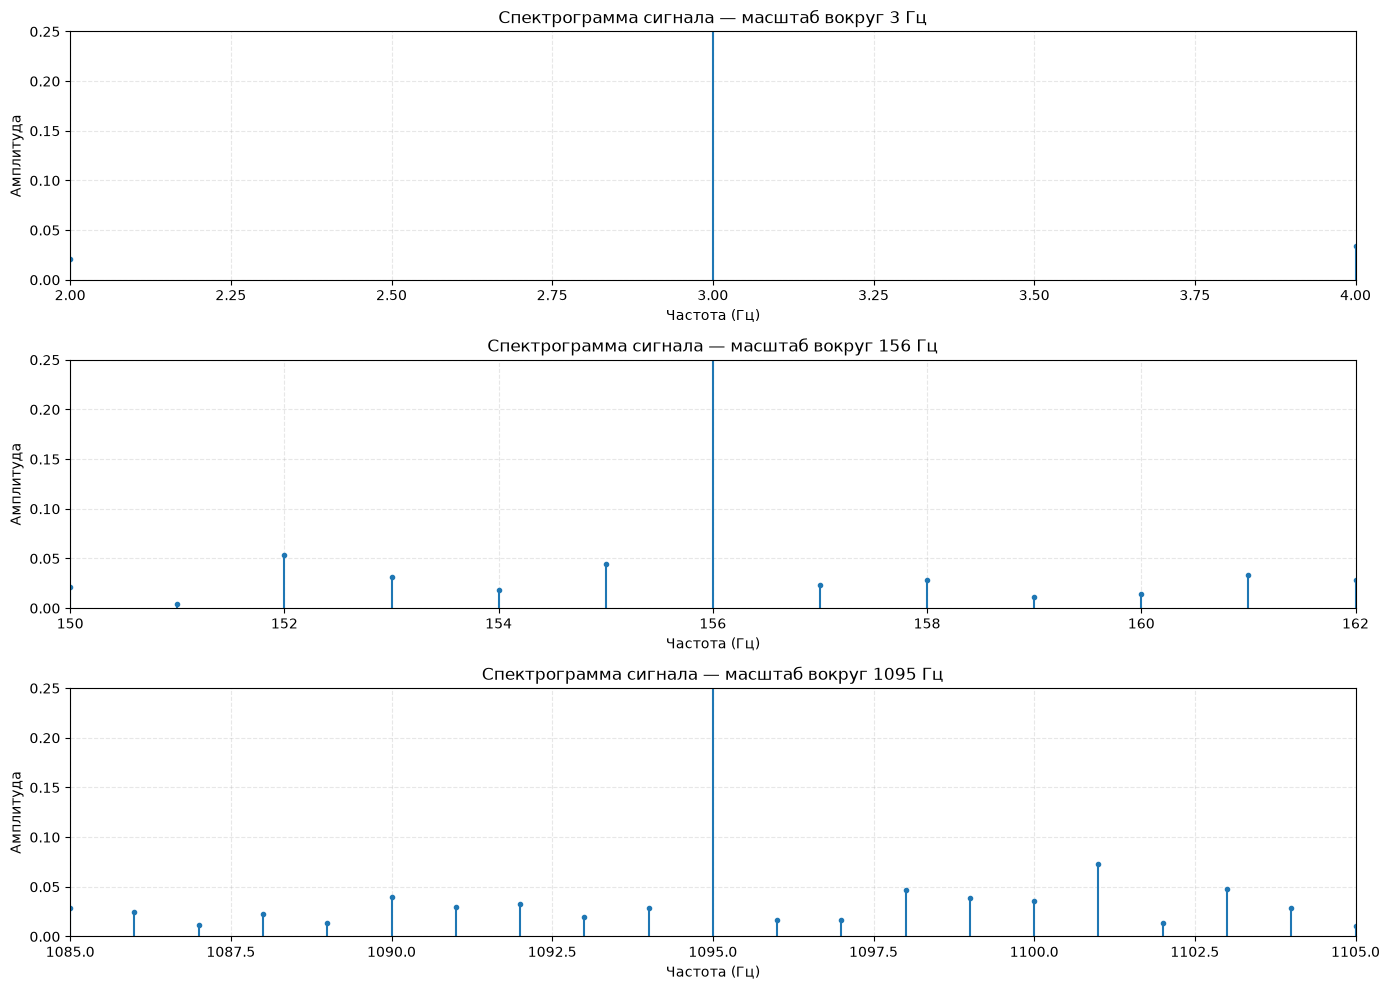

In [74]:
# === ОБНОВЛЁННЫЙ КОД С МАСШТАБОМ ПО Y ДО 0.25 ===

# Частотная ось в Гц
fs = n  # Частота дискретизации (26280 Гц)
freqs_hz = fftfreq(n=n, d=1 / fs)  # Частоты в Гц

# Только положительные частоты
positive_mask = freqs_hz >= 0
freqs_pos = freqs_hz[positive_mask]
fft_amp_pos = np.abs(y_fft[positive_mask]) * (2 / n)

# Создаём фигуру с 3 подграфиками
fig, axs = pyplot.subplots(3, 1, figsize=(14, 10))

# Настройки масштабирования: (мин. частота, макс. частота, подпись)
zoom_configs = [
    (2, 4, "3 Гц"),  # ±1 Гц вокруг 3 Гц
    (150, 162, "156 Гц"),  # ±6 Гц вокруг 156 Гц
    (1085, 1105, "1095 Гц"),  # ±10 Гц вокруг 1095 Гц
]

for idx, (f_min, f_max, freq_label) in enumerate(zoom_configs):
    # Фильтруем частоты в нужном диапазоне
    mask = (freqs_pos >= f_min) & (freqs_pos <= f_max)

    axs[idx].stem(freqs_pos[mask], fft_amp_pos[mask], markerfmt=".", basefmt=" ", linefmt="C0-")
    axs[idx].set_xlabel("Частота (Гц)")
    axs[idx].set_ylabel("Амплитуда")
    axs[idx].set_title(f"Спектрограмма сигнала — масштаб вокруг {freq_label}")
    axs[idx].grid(True, alpha=0.3, linestyle="--")
    axs[idx].set_xlim(f_min, f_max)
    # === ИЗМЕНЕНИЕ: фиксируем диапазон по вертикали [0; 0.25] ===
    axs[idx].set_ylim(0, 0.25)

pyplot.tight_layout()
pyplot.show()

Усложним пример, добавив к сигналу тренд, и посмотрим как изменится поведение частот сигнала в двух масштабах по оси частот.

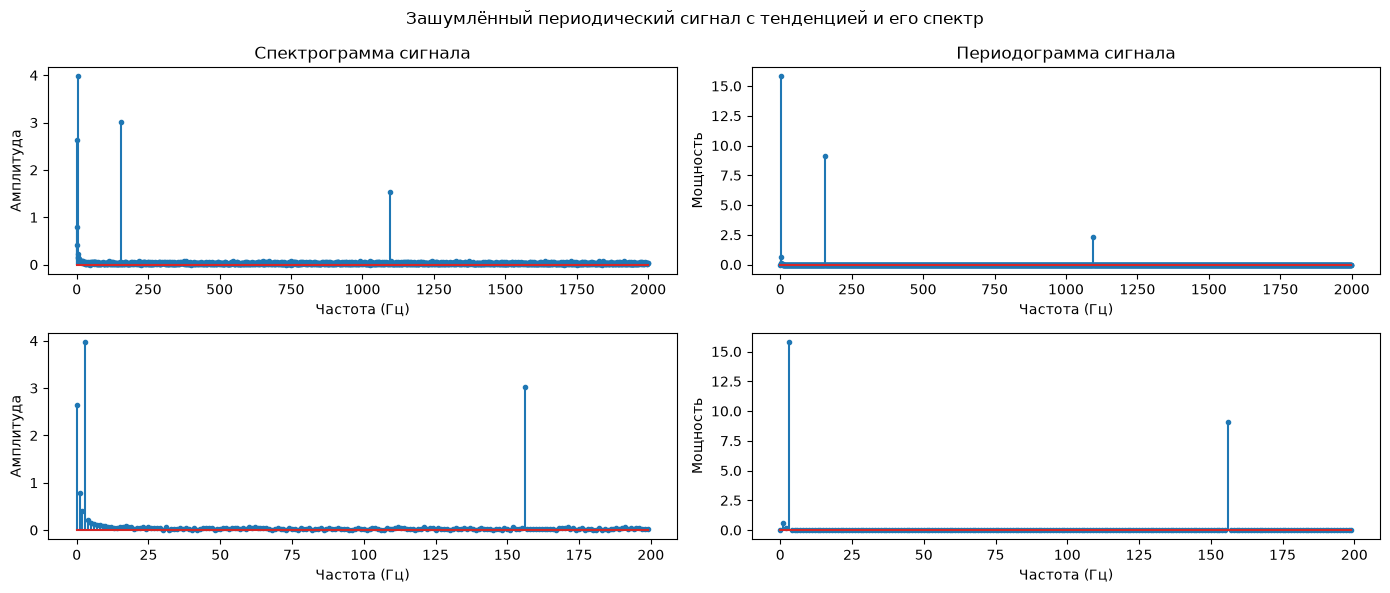

In [75]:
Fs = n  # частота дискретизации синтетического сигнала
trend = np.linspace(0.06, 2.5, n)
signal = xt_year + xt_week + xt_day + trend + norm_noise

y_fft = fft(x=signal)
freg_fft = fftfreq(n=n)

periodogramma = periodogram(x=signal)

fig, axs = pyplot.subplots(2, 2, figsize=(14, 6))
axs[0, 0].stem(
    freg_fft.copy()[:2000] / (1 / Fs), np.abs(y_fft.copy()[:2000]) * (2 / n), markerfmt="."
)
axs[0, 0].set_xlabel("Частота (Гц)")
axs[0, 0].set_ylabel("Амплитуда")
axs[0, 0].set_title("Спектрограмма сигнала")

axs[1, 0].stem(
    freg_fft.copy()[:200] / (1 / Fs), np.abs(y_fft.copy()[:200]) * (2 / n), markerfmt="."
)
axs[1, 0].set_xlabel("Частота (Гц)")
axs[1, 0].set_ylabel("Амплитуда")

axs[0, 1].stem(
    (periodogramma[0][:2000] / (1 / Fs)), (periodogramma[1][:2000] * (2 / n)), markerfmt="."
)
axs[0, 1].set_xlabel("Частота (Гц)")
axs[0, 1].set_ylabel("Мощность")
axs[0, 1].set_title("Периодограмма сигнала")

axs[1, 1].stem(
    (periodogramma[0][:200] / (1 / Fs)), (periodogramma[1][:200] * (2 / n)), markerfmt="."
)
axs[1, 1].set_xlabel("Частота (Гц)")
axs[1, 1].set_ylabel("Мощность")

pyplot.suptitle("Зашумлённый периодический сигнал с тенденцией и его спектр")
pyplot.show()

Наличие тренда вносит значительные изменения в низкочастотный диапазон спектра сигнала: появились пики с различной амплитудой между нулевой и доминирующей частотами. Пик на нулевой частоте говорит о том, что в сигнале имеется трендовая компонента. Также наблюдается искажение («дрожь») шума спектра сигнала. На периодограмме появился дополнительный пик рядом с доминирующим, который искажает интерпретацию.

Теперь посмотрим какие спектры у реального ряда. Возьмём почасовой ряд с температурными значениями.

In [76]:
df_temp = read_parquet(
    "https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_3/data/jena_climate_2009_2016_hour_grouped_data.parquet"
).asfreq("h")
temperature = df_temp["T (degC)"][:"2011"].to_numpy()

n = len(temperature)
time_vec = np.arange(0, 1, 1 / n)
Fs = 8760

In [77]:
def show_plot_temperature():
    """График температуры и её распределения"""
    _fig, axs = pyplot.subplots(2, 1)

    axs[0].plot(temperature)
    axs[0].set_title("Температура")
    axs[0].set_xlabel("Дата наблюдения")
    axs[0].set_ylabel("Градусов по Цельсию")
    axs[0].grid()

    axs[1].hist(temperature, bins=50, edgecolor="black")
    axs[1].set_title("Гистограмма распределения температуры")
    axs[1].set_xlabel("Градусов по Цельсию")
    axs[1].set_ylabel("Частота")

    pyplot.show()

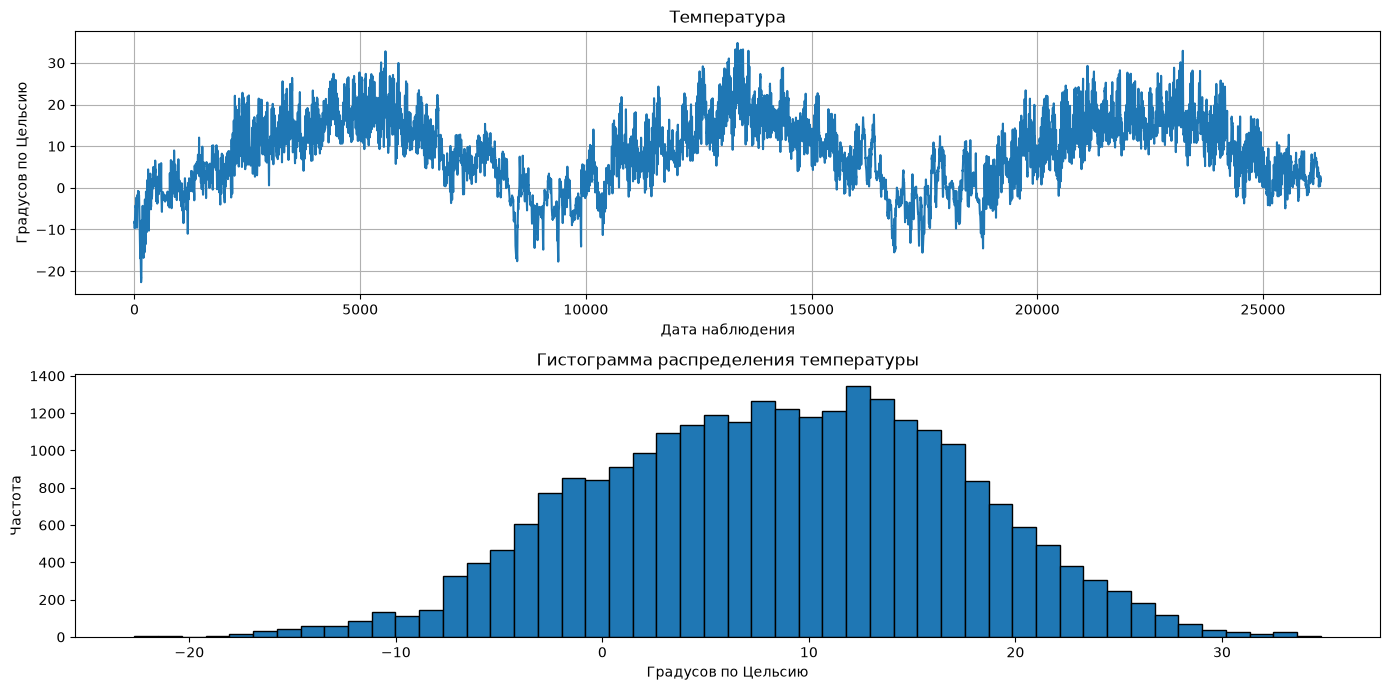

In [78]:
show_plot_temperature()

Выполним ДПФ и проанализируем результаты.

In [79]:
def plot_temperature_spectrum(data):
    """График со спектром температуры"""
    _fig, axs = pyplot.subplots(3, 1, figsize=(14, 7))

    # === График 1: Исходный сигнал ===
    axs[0].plot(data["xt"], label="Исходный сигнал")
    axs[0].set_xlabel("Время (сек.)")
    axs[0].set_ylabel("Температура (град. C)")
    axs[0].legend()
    axs[0].grid(True, alpha=0.3)

    # === График 2: Полный спектр ===
    axs[1].stem(data["freg_fft"], data["y_fft"], markerfmt=".", basefmt=" ", linefmt="C0-")
    axs[1].set_xlabel("Частота (Гц)")
    axs[1].set_ylabel("Амплитуда")
    axs[1].set_title("Полный спектр")
    axs[1].grid(True, alpha=0.3)

    # === График 3: Увеличенный масштаб до 15 Гц ===
    # Фильтруем данные: оставляем только частоты <= 15 Гц
    mask = data["freg_fft"] <= 15
    freq_zoom = data["freg_fft"][mask]
    amp_zoom = data["y_fft"][mask]

    axs[2].stem(freq_zoom, amp_zoom, markerfmt=".", basefmt=" ", linefmt="C0-")
    axs[2].set_xlabel("Частота (Гц)")
    axs[2].set_ylabel("Амплитуда")
    axs[2].set_title("Спектр в диапазоне 0–15 Гц (увеличенный масштаб)")
    axs[2].grid(True, alpha=0.3, linestyle="--")

    # === Ограничения осей ===
    axs[2].set_xlim(-1, 15)  # По горизонтали: до 15 Гц
    # axs[2].set_ylim(0, 0.25)    # По вертикали:  настраивайте при необходимости

    pyplot.suptitle("Дискретное преобразование Фурье на исходном ВР")
    pyplot.tight_layout()
    pyplot.show()

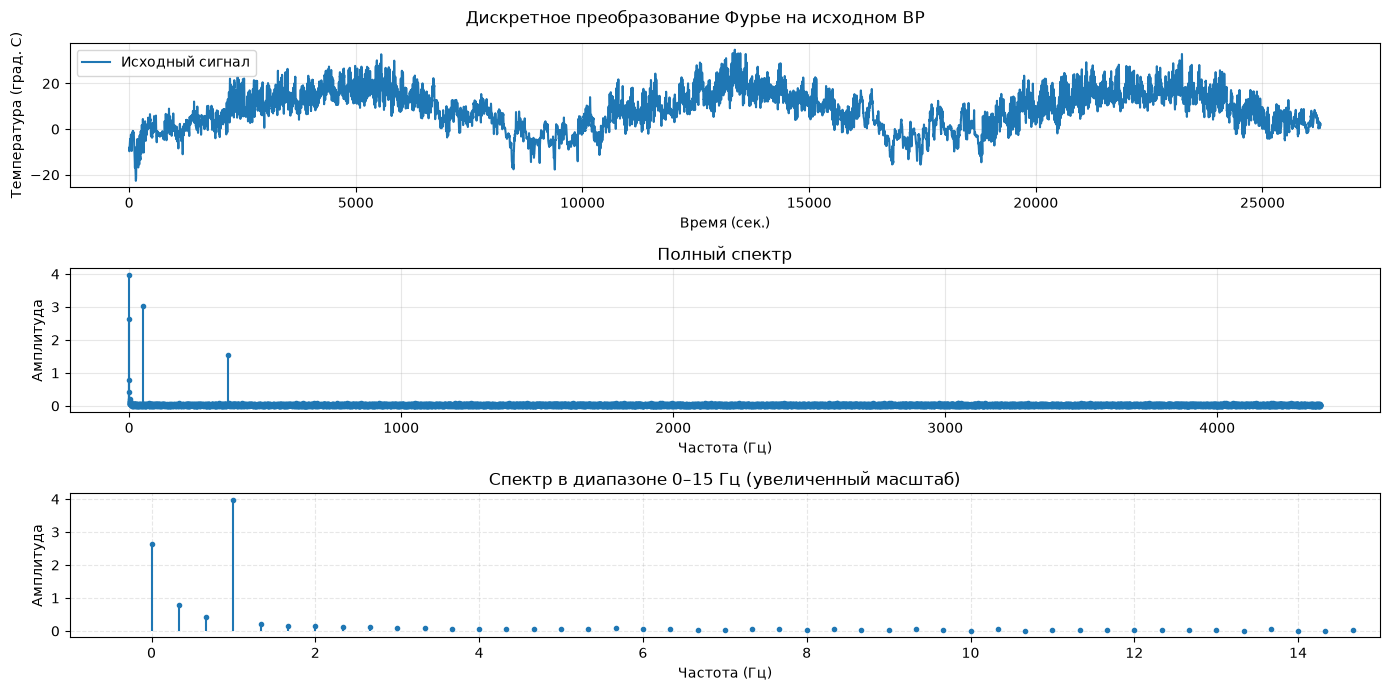

In [80]:
plot_temperature_spectrum(
    data={
        "xt": temperature,
        "freg_fft": freg_fft[: n // 2] / (1 / Fs),
        "y_fft": np.abs(y_fft[: n // 2]) * (2 / n),
    }
)

По спектру видно, что нулевая частота имеет самую большую амплитуду (в нашем случае равную 17). Это означает, что сигнал имеет так называемую постоянную составляющую. Наличие её в сигнале, равно как и тренда, может сильно усложнить (или исказить) анализ сигнала и интерпретацию его спектральных характеристик. Поэтому для качественного проведения анализа и более точного выявления его компонентов их обычно извлекают.

На самом деле, ДПФ позволяет работать с данными и без их предварительной подготовки в виде удаления постоянной составляющей или тренда, однако общее время обработки данных возрастёт. Искушение использовать все выявленные частоты, чтобы получить замечательные результаты, велико. Вопрос в том, целесообразно ли это? 

Для начала нам нужно решить в какой последовательности обработать (=извлечь) низкочастотные компоненты — тенденцию и постоянную составляющую.

## Локальное взвешенное сглаживание разброса (LOWESS)

Используется в STL декомпозиции.

У функции `lowess()` библиотеки statsmodels есть важный параметр `frac`, который определяет долю данных (или ширину окна), в которой выполняется локальная регрессия. Это позволяет настроить уровень сглаживания в зависимости от структуры рассматриваемых данных. С помощью функции plot_lowess_compare() построим график, на котором отобразим исходный сигнал, извлечённую тенденцию по методу свёртки и тенденции по методу LOWESS с различными значениями параметра `frac`, чтобы наглядно оценить, как разные значения `frac` влияют на сглаживание.

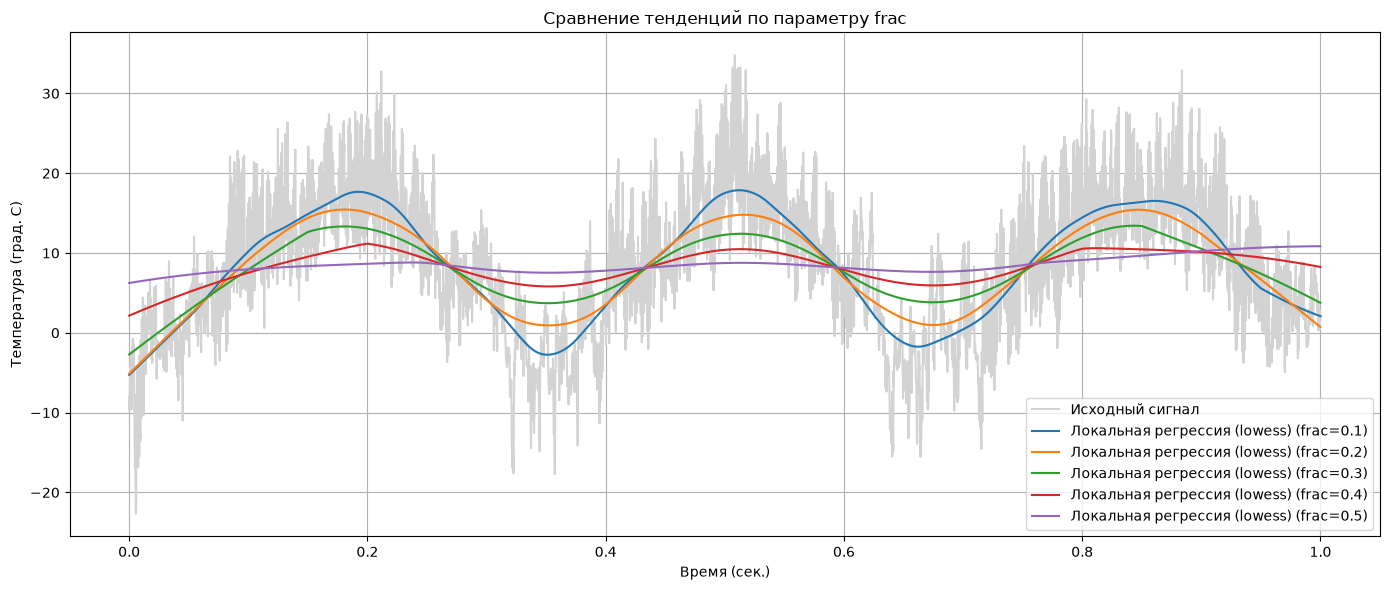

In [81]:
def plot_lowess_compare(data, frac_values):
    """График с исходным сигналом и тенденциями по свёртке и ЛВСР для разных значений frac"""
    pyplot.figure(figsize=(14, 6))

    pyplot.plot(data["time_vec"], data["temperature"], color="lightgray", label="Исходный сигнал")

    for frac in frac_values:
        lowess_res = lowess(data["temperature"], data["time_vec"], frac=frac)
        pyplot.plot(
            lowess_res[:, 0], lowess_res[:, 1], label=f"Локальная регрессия (lowess) (frac={frac})"
        )

    pyplot.title("Сравнение тенденций по параметру frac")
    pyplot.xlabel("Время (сек.)")
    pyplot.ylabel("Температура (град. C)")
    pyplot.legend(loc="best")
    pyplot.grid(True)
    pyplot.show()


plot_lowess_compare(
    data={"time_vec": time_vec, "temperature": temperature.copy(), "trend": trend},
    frac_values=[0.1, 0.2, 0.3, 0.4, 0.5],
)

По графику видно, что при малом значении `frac` LOWESS более чувствительно к локальным изменениям, а при большом — более сглаженное. 

Итак, извлечём из данных тенденцию с помощью функции `get_trend_lowess()` и вычтем её из сигнала.

In [82]:
def get_trend_lowess(endog, exog, frac):
    """Извлечение тенденции по методу ЛВСР"""
    print("Выполнение расчёта тенденции по методу ЛВСР ...")
    trend = lowess(endog, exog, frac)
    return trend[:, 1]


trend_lowess = get_trend_lowess(endog=temperature.copy(), exog=time_vec, frac=0.5)
processed_temp = temperature.copy() - trend_lowess

Выполнение расчёта тенденции по методу ЛВСР ...


Отобразим спектр обработанного сигнала.

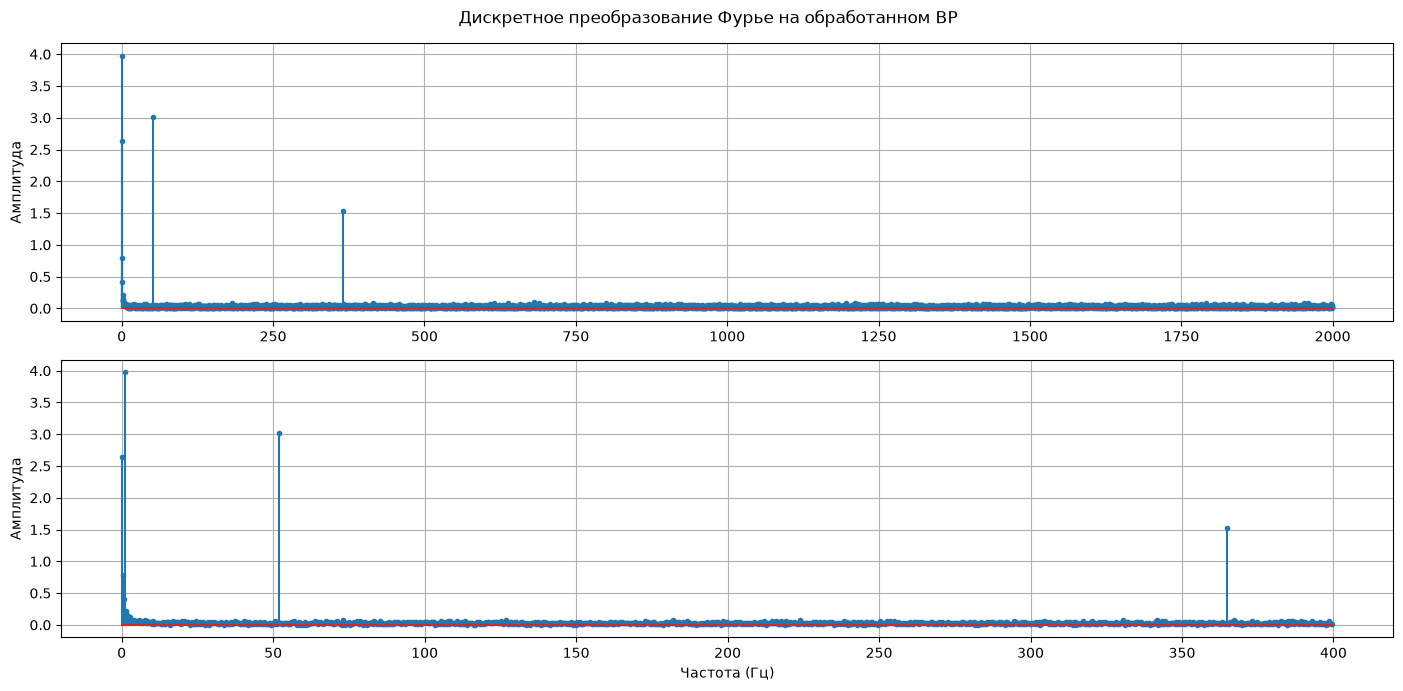

In [83]:
def plot_processed_temperature_spectrum(data):
    """График со спектром обработанной температуры"""
    _fig, axs = pyplot.subplots(2, 1, figsize=(14, 7))

    axs[0].stem(data["freg_fft"], data["y_fft"], markerfmt=".")
    axs[0].set_ylabel("Амплитуда")
    axs[0].grid(True)

    axs[1].stem(
        data["freg_fft"][: data["axs1_slice"]], data["y_fft"][: data["axs1_slice"]], markerfmt="."
    )
    axs[1].set_xlabel("Частота (Гц)")
    axs[1].set_ylabel("Амплитуда")
    axs[1].grid(True)

    pyplot.suptitle("Дискретное преобразование Фурье на обработанном ВР")
    pyplot.show()


plot_processed_temperature_spectrum(
    data={
        "freg_fft": freg_fft[:6000] / (1 / Fs),
        "y_fft": np.abs(y_fft[:6000]) * (2 / n),
        "axs1_slice": 1200,
    }
)

По результатам понятно, что анализ полученного спектра требует немало времени и значительных усилий для выявления необходимого количества частот с целью качественного прогнозирования годовой (да и дневной) сезонности.
Отфильтруем временной ряд по 3-й частоте, а затем сравним восстановление отфильтрованного сигнала по обоим способам — как с помощю `ifft()`, так и вручную.ю.

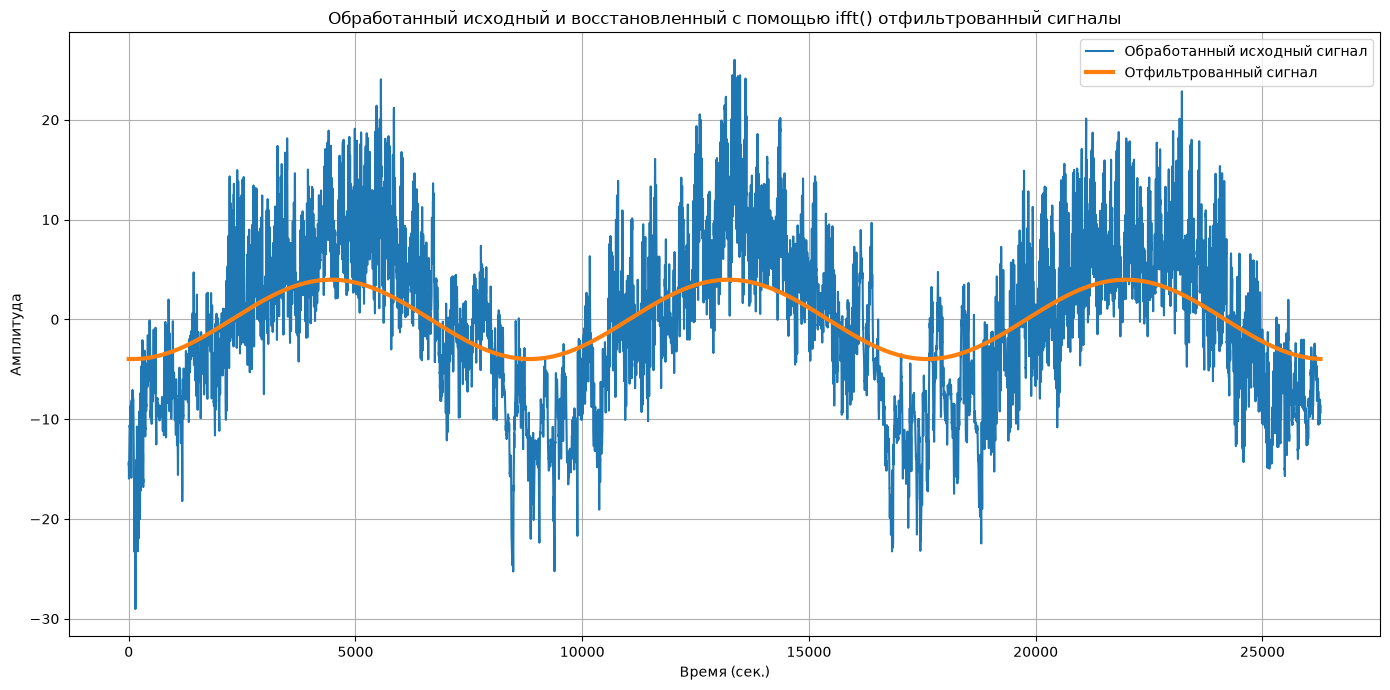

In [84]:
def filter_signal(y_fft, n, fregs_for_stay=3):
    """Фильтрация сигнала по частоте №3"""
    freg_fft = fftfreq(n=n)
    mask = np.isin(np.abs(freg_fft) / (1 / n), fregs_for_stay)
    filtered_fft = np.where(mask, y_fft, 0)
    return ifft(filtered_fft).real


x_inv = filter_signal(y_fft=y_fft, n=n)


def show_ifft_result_plot(data):
    """График с обработанным исходным и отфильтрованным сигналами"""
    pyplot.figure()
    pyplot.plot(data["processed_signal"], label="Обработанный исходный сигнал")
    pyplot.plot(data["filtered_signal"], linewidth=3, label="Отфильтрованный сигнал")
    pyplot.xlabel("Время (сек.)")
    pyplot.ylabel("Амплитуда")
    pyplot.legend(loc="best")
    pyplot.title(data["title"])
    pyplot.grid(True)
    pyplot.show()


show_ifft_result_plot(
    data={
        "processed_signal": processed_temp,
        "filtered_signal": x_inv,
        "title": "Обработанный исходный и восстановленный с помощью ifft() отфильтрованный сигналы",
    }
)

Восстановим сигнал вручную. Сначала с помощью функции `fft_result_filter()` отфильтруем данные по передаваемым в списке `fregs_for_stay` частотам. В основе функции уже известные вам действия. Для удобства предусмотрена фильтрация как по фактическим значениям частот (в этом случае явно указывается параметр d), так и преобразованными значениями частот по умолчанию (d=None). Затем выполняется ещё одна, результирующая, фильтрация по полученным частотам, чтобы оставить только те из них, у которых комплексные числа не равны нулю. 

Выполним фильтрацию по фактической частоте 1, определённой по спектрограмме с использованием частоты дискретизации, передав для этого параметру d значение Fs.

In [85]:
def fft_results_filter(fregs_for_stay, n, y_fft, d=None):
    """Фильтрация y_fft по частотам"""
    if d is None:
        freg_fft = fftfreq(n=n)
        mask = np.isin(np.abs(freg_fft) / (1 / n), fregs_for_stay)

    else:
        if not isinstance(d, int):
            raise ValueError("d должно быть целым числом")
        freg_fft = fftfreq(n=n, d=1 / d)
        mask = np.isin(np.abs(freg_fft), fregs_for_stay)

    filtered_fft = np.where(mask, y_fft, 0)

    df = DataFrame(
        data={"y_fft": filtered_fft, "fregs": freg_fft if d is None else freg_fft * 1 / d}
    )
    return df[df["y_fft"] != 0]


filtered_df = fft_results_filter(fregs_for_stay=[1], n=n, y_fft=y_fft, d=Fs)

In [86]:
filtered_df

,y_fft,fregs
3,-52140.524669+ 3258.763971j,0.000114
26277,-52140.524669- 3258.763971j,-0.000114


Далее нам нужно восстановить сигнал по отфильтрованным данным с помощью функции `get_signal_harmonics()`. Эта функция использует векторные/матричные операции перемножения, что значительно ускоряет выполнение расчётов. Она имеет два аргумента: dataframe (отфильтрованные данные) и time (массив моментов времени).

Сначала из dataframe извлекаются столбцы `y_fft` и `fregs`, преобразуются в numpy-массивы и приводятся к фактическим значениям. Затем с помощью reshape(-1, 1) форма массивов изменяется с 1Д на 2Д (например, если в dataframe размерность столбца составляет (2,), то после reshape(-1, 1) мы получаем размерность (2, 1)). В итоге мы получаем две матрицы An и fn с размерностью (2, 1) в фактических масштабах значений.

Далее создаётся 1Д-массив комплексных чисел xt для хранения результата.

Затем выполняется перемножение массивов с использованием алгоритма автоматического расширения массивов numpy broadcasting. Поскольку time - это вектор с размерностью (26280,), то numpy «растянет» An и fn до размерности (2, 26280). Это означает, что каждое значение из An и fn будет применено ко всем значениям time для каждой гармоники, а time будет «размножен» по строкам, чтобы соответствовать размерности 2 (то есть у нас будет 2 строки и 26280 столбцов). Результатом будет массив xt с размерностью (2, 26280).

На последнем шаге создаётся словарь, в котором ключи - это индексы оригинального dataframe, а значения - строки массива xt. Каждая строка xt соответствует результату для каждого индекса и представляет собой одномерный массив длиной 26280 точек.

Итоговая структура данных - это словарь, где каждому индексу соответствует массив комплексных чисел.

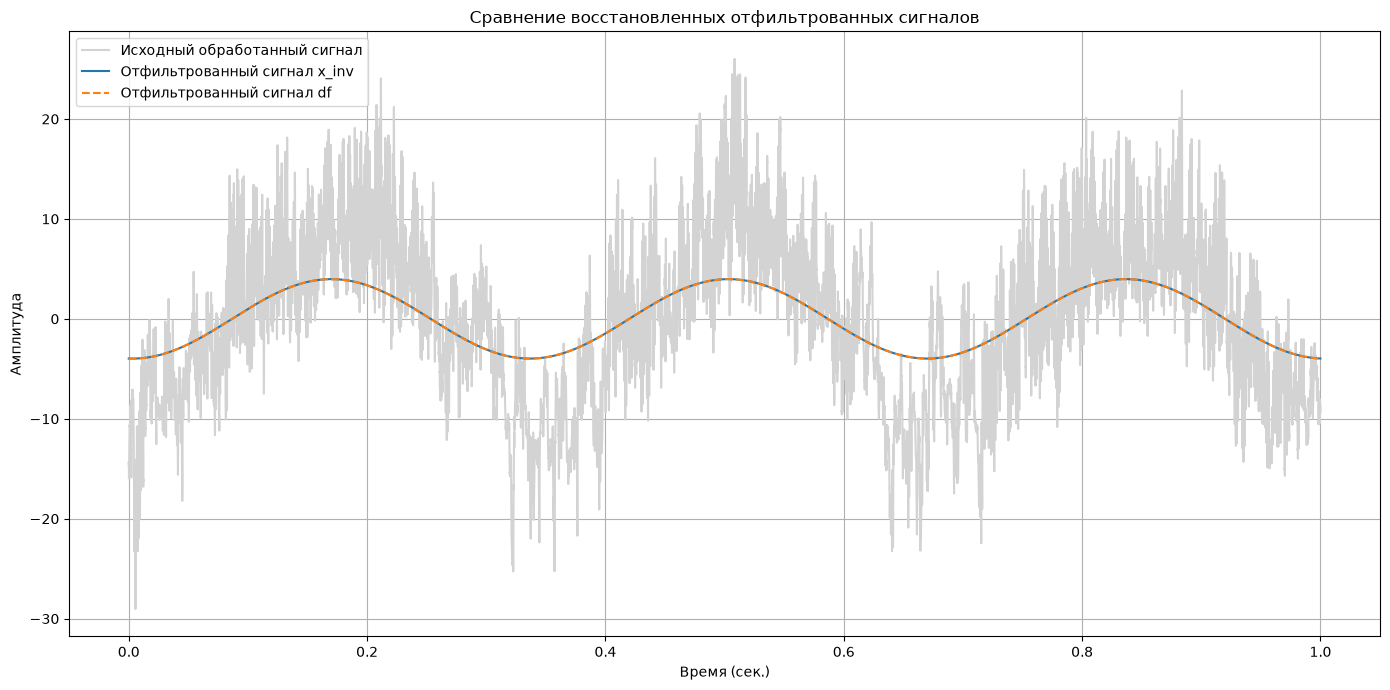

In [87]:
def get_signal_harmonics_exp(dataframe, time):
    """Получение гармоник отфильтрованного сигнала с помощью np.exp()"""
    An = (dataframe["y_fft"].to_numpy() * (1 / n)).reshape(-1, 1)
    fn = (dataframe["fregs"].to_numpy() / (1 / n)).reshape(-1, 1)
    xt = np.zeros(len(dataframe), dtype=complex)
    k = np.arange(len(time))
    xt = An * np.exp(2j * np.pi * fn * k / len(time))
    return {str(index): xt_row for index, xt_row in zip(dataframe.index, xt)}


harmonics_dict = get_signal_harmonics_exp(dataframe=filtered_df.copy(), time=time_vec)


def show_harmonics_processed_signal(data):
    """График сигнала, восстановленного вручную по гармоникам"""
    text_1 = "Исходный обработанный сигнал"
    text_2 = "Отфильтрованный сигнал x_inv"
    text_3 = "Отфильтрованный сигнал df"

    pyplot.figure()
    pyplot.plot(data["time_vec"], data["processed_temp"], color="lightgray", label=text_1)
    pyplot.plot(data["time_vec"], data["x_inv"].real, label=text_2)
    pyplot.plot(data["time_vec"], data["sum_signal"].real, label=text_3, linestyle="dashed")
    pyplot.xlabel("Время (сек.)")
    pyplot.ylabel("Амплитуда")
    pyplot.legend(loc="best")
    pyplot.title("Сравнение восстановленных отфильтрованных сигналов")
    pyplot.grid(True)
    pyplot.show()


show_harmonics_processed_signal(
    data={
        "time_vec": time_vec,
        "processed_temp": processed_temp,
        "x_inv": x_inv,
        "sum_signal": np.sum(list(harmonics_dict.values()), axis=0),
    }
)

Давайте ещё раз посмотрим на спектрограмму.

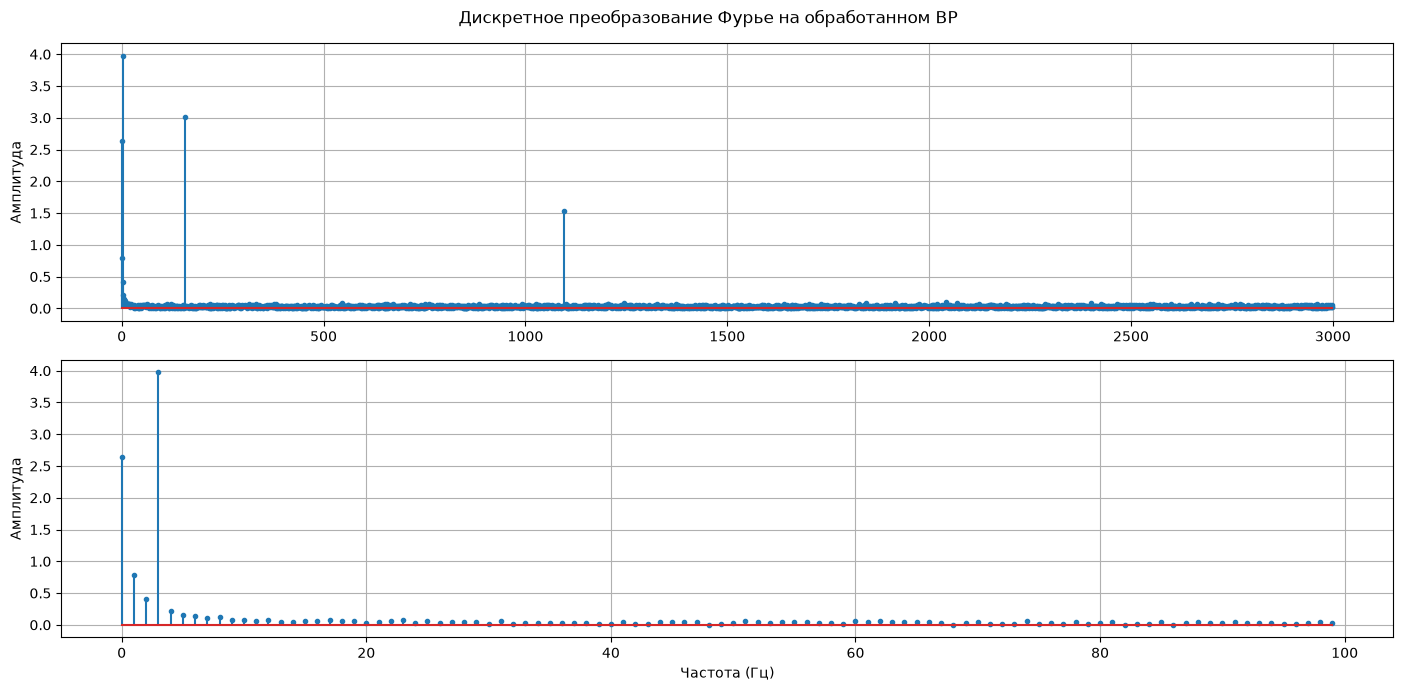

In [88]:
plot_processed_temperature_spectrum(
    data={
        "freg_fft": freg_fft[:3000] / (1 / n),
        "y_fft": np.abs(y_fft[:3000]) * (2 / n),
        "axs1_slice": 100,
    }
)

Для моделирования годовой сезонности я буду использовать диапазон частот от 1 до 19 включительно. Сравнение исходного обработанного сигнала с восстановленным по этим частотам сигналом представлено на следующем графике.

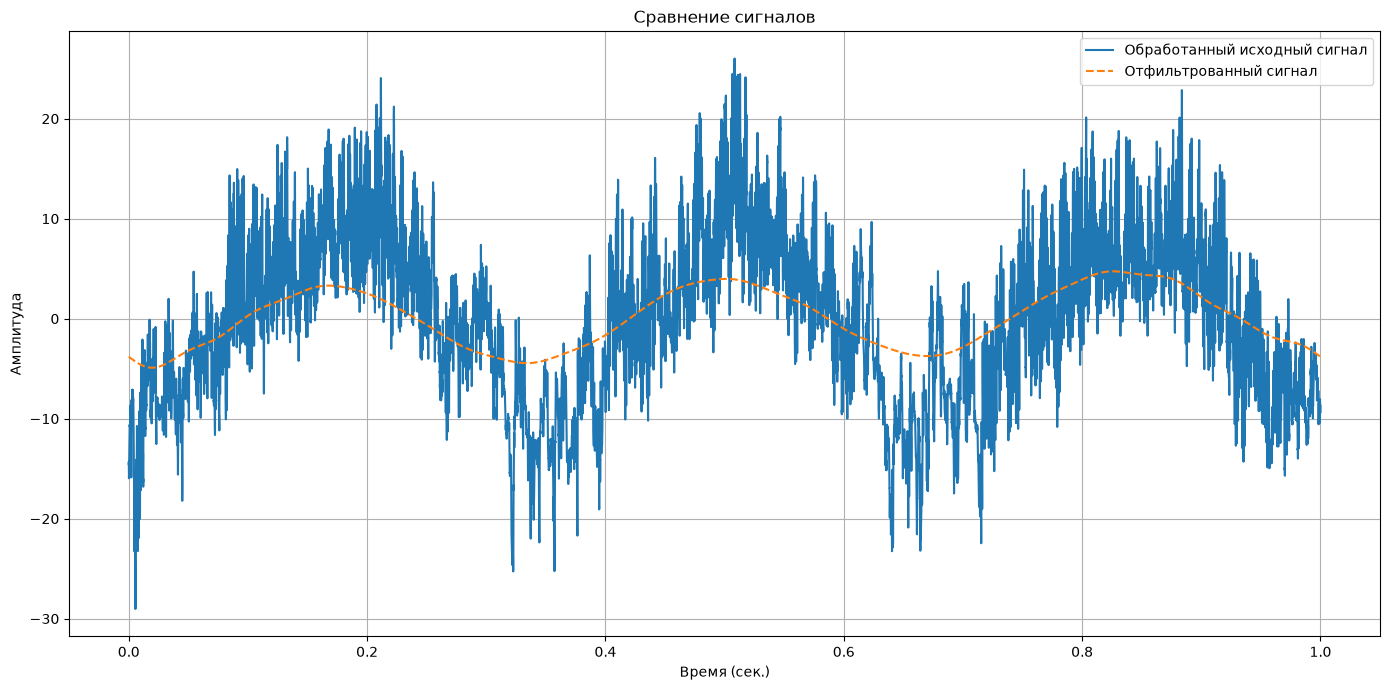

In [89]:
fregs_for_stay = list(range(1, 20))  # d=n

filtered_df = fft_results_filter(fregs_for_stay=fregs_for_stay, n=n, y_fft=y_fft)

harmonics_dict = get_signal_harmonics_exp(dataframe=filtered_df.copy(), time=time_vec)


def show_harmonics_sum_signal(data):
    """График сигнала, восстановленного вручную по гармоникам"""
    text_1 = "Обработанный исходный сигнал"
    text_2 = "Отфильтрованный сигнал"

    pyplot.figure()
    pyplot.plot(data["time_vec"], data["processed_temp"], label=text_1)
    pyplot.plot(data["time_vec"], data["sum_signal"].real, label=text_2, linestyle="dashed")
    pyplot.xlabel("Время (сек.)")
    pyplot.ylabel("Амплитуда")
    pyplot.legend(loc="best")
    pyplot.title("Сравнение сигналов")
    pyplot.grid(True)
    pyplot.show()


show_harmonics_sum_signal(
    data={
        "time_vec": time_vec,
        "processed_temp": processed_temp,
        "sum_signal": np.sum(list(harmonics_dict.values()), axis=0),
    }
)

Отобразим на графике гармоники полученной годовой сезонности по отдельности и внимательно их рассмотрим.

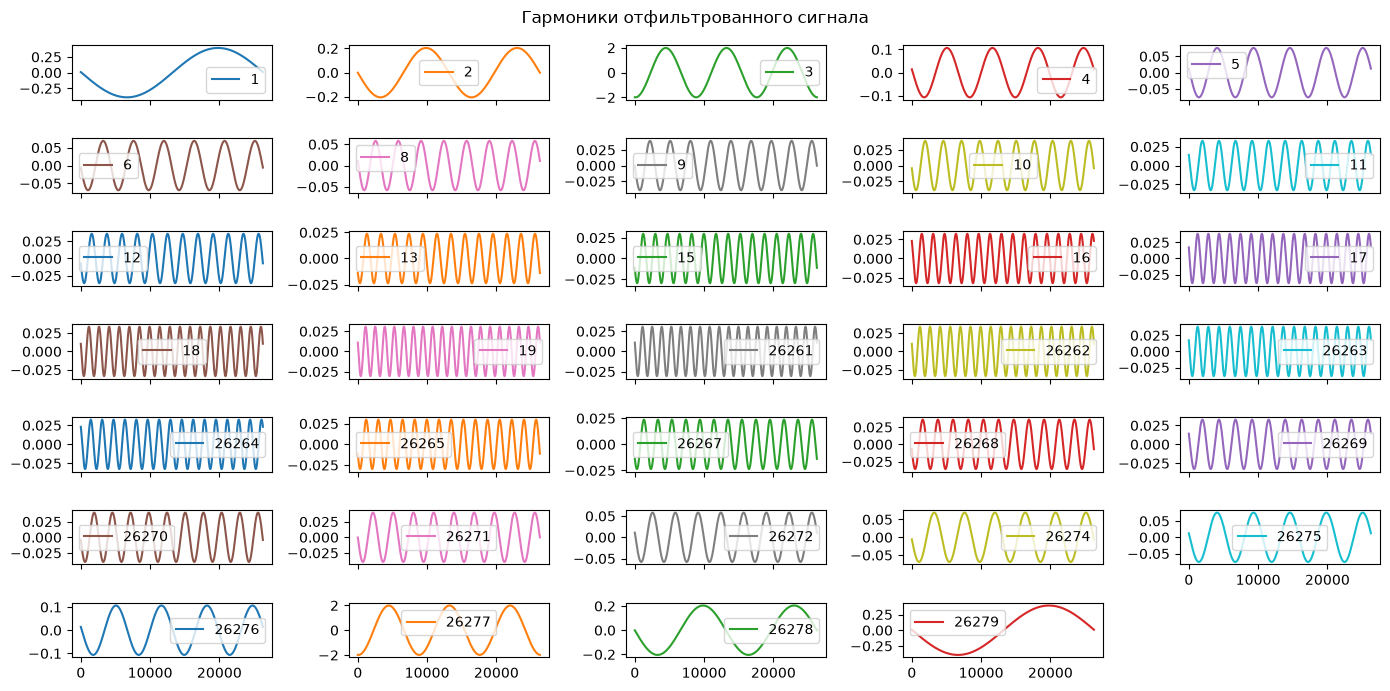

In [90]:
def show_harmonics(harmonics_dict):
    """График с гармониками отфильтрованного сигнала"""
    df = DataFrame({key: value.real for key, value in harmonics_dict.items()})

    df.plot(
        subplots=True, layout=(7, 5), figsize=(14, 7), title="Гармоники отфильтрованного сигнала"
    )

    pyplot.show()


show_harmonics(harmonics_dict=harmonics_dict)

Видно, что полученная годовая сезонность определяется гармониками с различными амплитудами, частотами и фазами. Поэтому - в данном случае - экстраполирование каждой гармоники отдельно от суммированного сигнала - это далеко не самая лучшая идея. Обычно при наличие одной сезонности экстраполируют «целостный», суммированный, сигнал, учитывающий совокупное поведение всех периодических составляющих. Такой подход сохраняет взаимосвязь между всеми гармониками, что, в свою очередь, позволяет моделировать сезонность более точно и с меньшими затратами на вычислительные ресурсы. 

Давайте займёмся подготовкой входных данных.

In [91]:
def get_centered_temperature(data):
    """Центрирование сигнала вокруг нуля"""
    mean_value = np.mean(data)
    return mean_value, data - mean_value


mean_value, processed_temp = get_centered_temperature(data=processed_temp.copy())

In [92]:
def prepare_input_data(data):
    """Подготовка входных данных модели"""
    return {
        "endog_train": data["endog_train"],
        "endog_val": data["endog_val"],
        "exog_train": Series(
            data["exog_train"], index=data["exog_train_index"], name="Filtered_signal_train"
        ),
    }


input_data = prepare_input_data(
    data={
        "endog_train": df_temp["T (degC)"][:"2011"].copy(),
        "endog_val": df_temp["T (degC)"]["2012-01-01":"2012-01-07"].copy(),
        "exog_train": np.sum(list(harmonics_dict.values()), axis=0) + mean_value + trend_lowess,
        "exog_train_index": df_temp[:"2011"].index,
    }
)

Подготовка экзогенной валидационной части требует дополнительных действий. Сперва экстраполируем полученную суммированную годовую сезонность с помощью функции `get_sum_signal_ext()`. Используя функцию `show_sum_signal_ext()`, отобразим на графике обе сезонности - «тренировочную» и «валидационную».

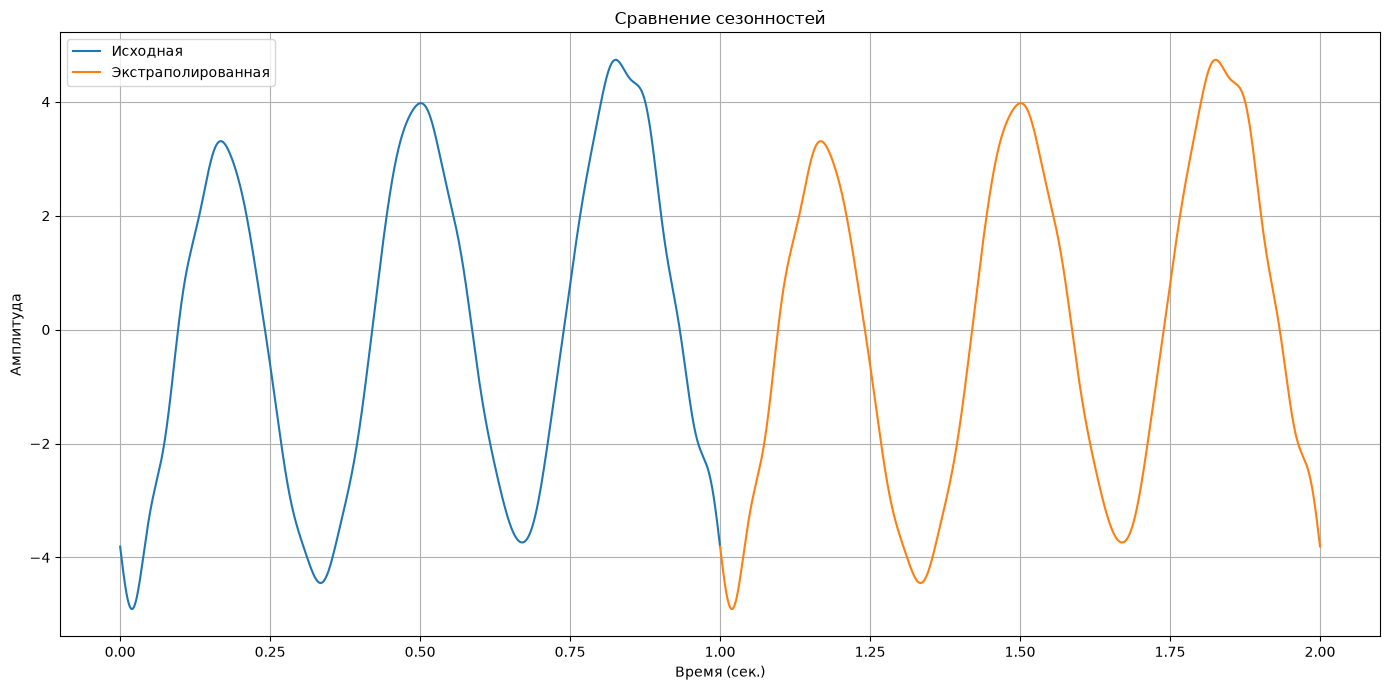

In [93]:
def get_sum_signal_ext(dataframe, time):
    """Экстраполяция отфильтрованного суммированного сигнала годовой сезонности"""
    An = (dataframe["y_fft"].to_numpy() * (1 / n)).reshape(-1, 1)
    fn = (dataframe["fregs"].to_numpy() / (1 / n)).reshape(-1, 1)
    # xt = np.zeros(len(dataframe), dtype=complex)
    k = np.arange(len(time))
    return np.sum(list(An * np.exp(2j * np.pi * fn * k / len(time))), axis=0)


harmonics_values_ext = get_sum_signal_ext(dataframe=filtered_df.copy(), time=np.arange(1, 2, 1 / n))


def show_sum_signal_ext(data):
    """График с исходной и экстраполированной сезонностями"""
    pyplot.figure()
    pyplot.plot(data["time_vec"], data["sum_signal"], label="Исходная")
    pyplot.plot(data["time_vec_ext"], data["sum_signal_ext"], label="Экстраполированная")
    pyplot.xlabel("Время (сек.)")
    pyplot.ylabel("Амплитуда")
    pyplot.legend(loc="best")
    pyplot.title("Сравнение сезонностей")
    pyplot.grid(True)
    pyplot.show()


show_sum_signal_ext(
    data={
        "time_vec": time_vec,
        "time_vec_ext": np.arange(1, 2, 1 / n),
        "sum_signal": (np.sum(list(harmonics_dict.values()), axis=0)).real,
        "sum_signal_ext": harmonics_values_ext.real,
    }
)

Следует понимать, что при использовании большого количества частот, определённых с помощью дискретного преобразования Фурье для восстановления сигнала, годовые сезонные колебания для всех рассматриваемых годов становятся менее унифицированными.